# Economy, Energy Mix, and Responsibility in Global CO2 Emissions

This notebook asks: **why do national CO2 emissions differ so sharply, and which accounting lens changes the answer?**

The argument is more nuanced than "rich countries emit more." Economic development is strongly associated with higher emissions per person, but the final emissions outcome also depends on energy demand, fuel mix, trade accounting, land-use change, and long-run structural change.

**Investigation map**

| Section | Claim tested | Evidence used |
|---|---|---|
| Data audit | The raw OWID panel has uneven coverage, so each hypothesis needs its own defensible year/sample. | Missingness, country coverage, codebook units |
| Baseline | National emissions responsibility is concentrated, not evenly distributed. | Top-emitter shares, Lorenz curve, Gini index |
| H1 Economy | GDP per capita predicts CO2 per capita, but not CO2 per GDP. | Spearman correlations, labeled scatterplots |
| H2 Energy mix | Energy demand and coal share explain more than GDP alone. | Permutation test, bootstrap interval, OLS model comparison |
| H3 Trade/change | Production vs consumption accounting changes responsibility; post-1990 paths diverge. | Trade-adjusted emissions, indexed time series |
| H4 Decoupling | GDP growth does not always require territorial CO2 growth. | 1990-2022 growth accounting, decoupling classes, z/proportion tests, regression |
| H5 Land use | Fossil CO2 alone can understate emissions in land-use-intensive economies. | CO2 with and without land-use change |
| H6 Historical responsibility | Current emissions and cumulative responsibility identify different countries. | Current-vs-cumulative shares, Gini difference, bootstrap test, rank shifts |


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust paths: works whether the kernel starts in the repo root or notebooks/.
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'data/raw/owid-co2-data.csv').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not find data/raw/owid-co2-data.csv')

DATA = PROJECT_ROOT / 'data/raw/owid-co2-data.csv'
CODEBOOK = PROJECT_ROOT / 'data/raw/owid-co2-codebook.csv'
FIGURES = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

pd.options.display.float_format = '{:,.3f}'.format

df = pd.read_csv(DATA)
codebook = pd.read_csv(CODEBOOK)
countries = df[df['iso_code'].notna() & (df['iso_code'].str.len() == 3)].copy()

print('Rows, columns:', df.shape)
print('Years:', int(df['year'].min()), 'to', int(df['year'].max()))
print('Country-year rows after aggregate removal:', countries.shape[0])
print('Countries/territories with ISO codes:', countries['country'].nunique())
countries.head()


Rows, columns: (50411, 79)
Years: 1750 to 2024
Country-year rows after aggregate removal: 42480
Countries/territories with ISO codes: 218


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,"2,802,560.000",NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data and Scope

The analysis uses the Our World in Data CO2 dataset. It includes country-year observations for emissions, population, GDP, energy use, fuel-specific emissions, consumption-based emissions, and trade-adjusted emissions.

Different indicators have different latest usable years, so we use the newest year with broad country coverage for each question:

- 2022 for GDP-heavy and energy-per-capita analysis.
- 2023 for consumption and trade-adjusted emissions.
- 2024 for fuel-mix and latest territorial emissions analysis.

Countries with very small populations are filtered out in the hypothesis tests to keep microstate outliers from driving the results. The analysis is observational, so it tests associations and structural patterns rather than proving a single policy caused a national emissions path.


## Basic Cleaning

The dataset starts as a mostly raw country-year panel. Before doing hypothesis-specific filters, we first apply a small, transparent cleaning layer:

- Remove exact duplicate rows, if any.
- Keep only country/territory observations with three-letter ISO codes, removing aggregates such as `World`, continents, and income groups.
- Require the basic identifiers `country`, `year`, and `iso_code` for the country-level analysis.
- Check impossible or suspicious values in core variables such as population, CO2, and GDP.

This is intentionally conservative. We do **not** globally drop high-missingness columns or impute values, because different indicators have different historical coverage. Later sections still do their own `dropna(...)`, year selection, population thresholds, and log-transform validity checks based on the variables needed for that specific question.


In [2]:
raw_shape = df.shape
exact_duplicates = int(df.duplicated().sum())
essential_missing = df[['country', 'year', 'iso_code']].isna().sum().to_dict()
aggregate_or_non_country = int((df['iso_code'].isna() | (df['iso_code'].astype(str).str.len() != 3)).sum())

basic = df.drop_duplicates().copy()
basic_countries = basic[basic['iso_code'].notna() & (basic['iso_code'].str.len() == 3)].copy()
basic_countries = basic_countries.dropna(subset=['country', 'year', 'iso_code'])
basic_countries['year'] = basic_countries['year'].astype(int)

quality_checks = pd.DataFrame([
    {'check': 'raw rows', 'value': raw_shape[0]},
    {'check': 'raw columns', 'value': raw_shape[1]},
    {'check': 'exact duplicate rows removed', 'value': exact_duplicates},
    {'check': 'aggregate/non-country rows removed', 'value': aggregate_or_non_country},
    {'check': 'country-year rows retained', 'value': len(basic_countries)},
    {'check': 'unique countries/territories retained', 'value': basic_countries['country'].nunique()},
])
display(quality_checks)

core_ranges = basic_countries[['population', 'gdp', 'co2', 'co2_per_capita']].describe(percentiles=[0.01, 0.5, 0.99]).T
core_ranges[['count', 'min', '1%', '50%', '99%', 'max']]


,check,value
0,raw rows,50411
1,raw columns,79
2,exact duplicate rows removed,0
3,aggregate/non-country rows removed,7931
4,country-year rows retained,42480
5,unique countries/territories retained,218


,count,min,1%,50%,99%,max
population,"38,332.000",215.000,"2,654.000","1,956,692.500","248,809,249.420","1,450,935,785.000"
gdp,"15,230.000","49,980,000.000","216,937,740.530","27,392,125,874.000","3,627,283,236,983.758","26,966,016,991,166.000"
co2,"23,408.000",0.000,0.000,2.776,"1,315.657","12,289.037"
co2_per_capita,"22,945.000",0.000,0.000,1.009,32.625,782.743


In [3]:
# Use the cleaned country-level panel for all following analysis.
countries = basic_countries.copy()

suspicious_rows = pd.DataFrame({
    'issue': [
        'population <= 0',
        'negative territorial CO2',
        'negative GDP',
        'missing country-year duplicate keys',
    ],
    'rows': [
        int((countries['population'].notna() & (countries['population'] <= 0)).sum()),
        int((countries['co2'].notna() & (countries['co2'] < 0)).sum()),
        int((countries['gdp'].notna() & (countries['gdp'] < 0)).sum()),
        int(countries.duplicated(subset=['country', 'year']).sum()),
    ]
})
suspicious_rows


,issue,rows
0,population <= 0,0
1,negative territorial CO2,0
2,negative GDP,0
3,missing country-year duplicate keys,0


### Basic Cleaning Takeaway

The cleaned panel now excludes aggregate regions and obvious duplicate records, while preserving the raw indicator columns for later analysis. The important choice is methodological: missingness is handled locally inside each hypothesis, because a blanket rule would incorrectly remove useful variables such as consumption-based emissions, GDP, or land-use change just because they have shorter coverage windows.


,column,title,unit
0,co2,Annual CO₂ emissions,million tonnes (Mt)
1,co2_including_luc,Annual CO₂ emissions including land-use change,million tonnes (Mt)
2,co2_per_capita,CO₂ emissions per capita,tonnes per person (t/person)
3,co2_per_gdp,Annual CO₂ emissions per GDP (kg per internati...,kilograms per international-$ (kg/$)
4,co2_per_unit_energy,Annual CO₂ emissions per unit energy (kg per k...,kilograms per kilowatt-hour (kg/kWh)
5,coal_co2,Annual CO₂ emissions from coal,million tonnes (Mt)
6,consumption_co2,Annual consumption-based CO₂ emissions,million tonnes (Mt)
7,energy_per_capita,Primary energy consumption per capita,kilowatt-hours per person (kWh)
8,gas_co2,Annual CO₂ emissions from gas,million tonnes (Mt)
9,gdp,Gross domestic product (GDP),international-$ in 2011 prices ($)


,section,latest_year_with_80plus_countries,country_count,required_columns
0,GDP + population + CO2,2022,164,"gdp, population, co2, co2_per_capita"
1,Trade/consumption CO2,2023,120,"consumption_co2, trade_co2_share, co2"
2,Energy intensity,2023,203,"energy_per_capita, co2_per_unit_energy"
3,Fuel mix,2024,110,"coal_co2, oil_co2, gas_co2, co2"
4,Land-use accounting,2024,194,"co2, co2_including_luc, land_use_change_co2"


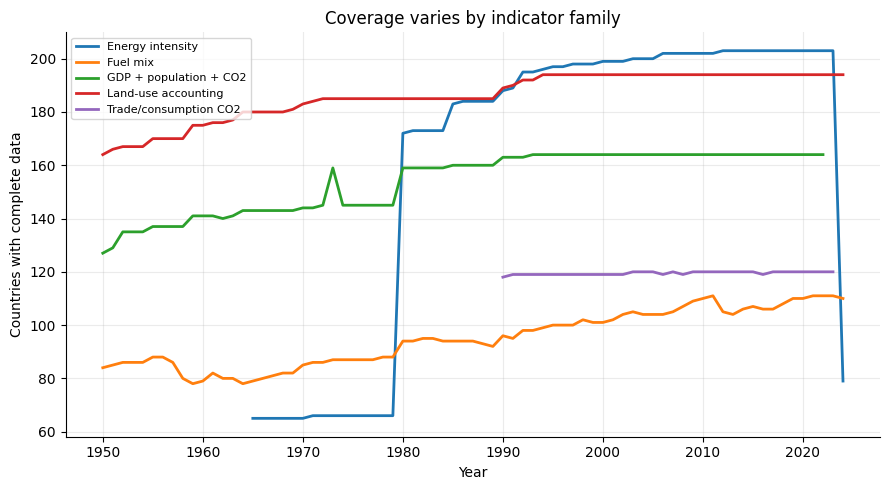

In [4]:
key_columns = [
    'co2', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy',
    'gdp', 'population', 'energy_per_capita', 'coal_co2', 'oil_co2', 'gas_co2',
    'consumption_co2', 'trade_co2_share', 'co2_including_luc', 'land_use_change_co2',
]

variable_glossary = (
    codebook[codebook['column'].isin(key_columns)]
    [['column', 'title', 'unit']]
    .sort_values('column')
    .reset_index(drop=True)
)
display(variable_glossary)

coverage_specs = {
    'GDP + population + CO2': ['gdp', 'population', 'co2', 'co2_per_capita'],
    'Trade/consumption CO2': ['consumption_co2', 'trade_co2_share', 'co2'],
    'Energy intensity': ['energy_per_capita', 'co2_per_unit_energy'],
    'Fuel mix': ['coal_co2', 'oil_co2', 'gas_co2', 'co2'],
    'Land-use accounting': ['co2', 'co2_including_luc', 'land_use_change_co2'],
}

rows = []
coverage_by_year = []
for label, cols in coverage_specs.items():
    valid = countries.dropna(subset=cols)
    counts = valid.groupby('year').size()
    latest = counts[counts >= 80].index.max()
    rows.append({
        'section': label,
        'latest_year_with_80plus_countries': latest,
        'country_count': int(counts.loc[latest]),
        'required_columns': ', '.join(cols),
    })
    for year, count in counts.items():
        coverage_by_year.append({'year': year, 'section': label, 'country_count': count})

coverage_table = pd.DataFrame(rows)
display(coverage_table)

coverage_plot = pd.DataFrame(coverage_by_year)
fig, ax = plt.subplots(figsize=(9, 5))
for label, group in coverage_plot[coverage_plot['year'] >= 1950].groupby('section'):
    ax.plot(group['year'], group['country_count'], label=label, linewidth=2)
ax.set_title('Coverage varies by indicator family')
ax.set_xlabel('Year')
ax.set_ylabel('Countries with complete data')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'audit_coverage_by_year.png', dpi=180)
plt.show()


## Exploratory Data Analysis

The EDA section gives a broad picture before the formal hypotheses. It borrows the useful parts of `co2_story.ipynb`--global trends, source breakdowns, country comparisons, and correlations--but adds more defensible filters and more analytical summaries.

The goal here is not to settle every hypothesis yet. It is to identify patterns that justify the later tests.


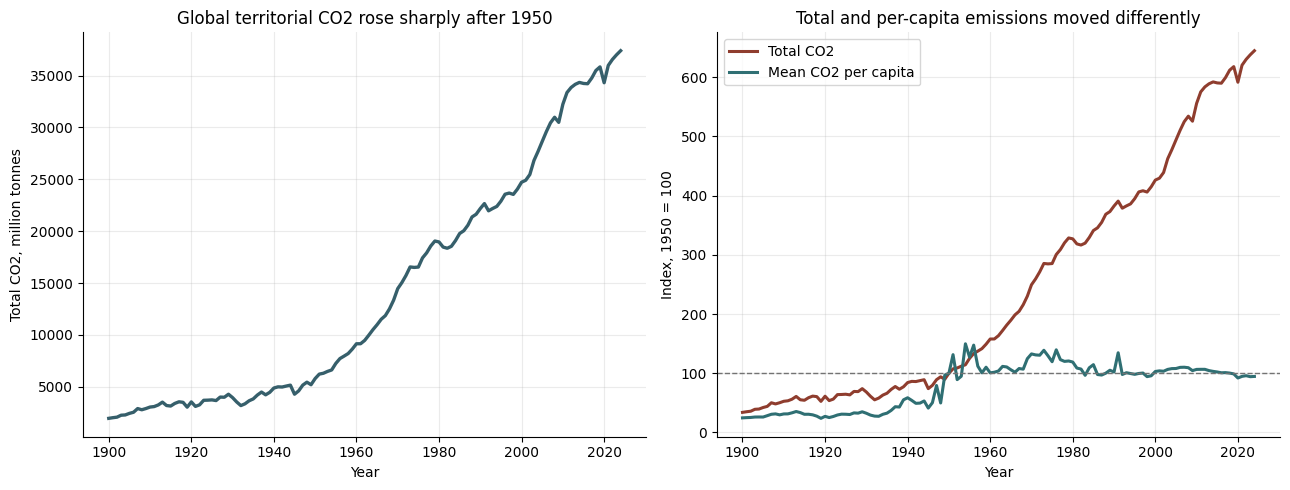

,year,total_co2,mean_co2_per_capita,median_co2_per_capita,reporting_countries,population,total_co2_index_1950_100,mean_pc_index_1950_100
270,2020,"34,310.228",4.502,2.844,215,"7,878,476,526.000",591.586,91.921
271,2021,"35,978.968",4.638,3.073,215,"7,945,936,851.000",620.359,94.689
272,2022,"36,553.536",4.692,3.162,215,"8,012,919,008.000",630.266,95.797
273,2023,"37,003.074",4.611,3.139,215,"8,083,244,776.000",638.017,94.148
274,2024,"37,398.067",4.632,3.204,215,"8,153,471,000.000",644.828,94.564


In [5]:
global_by_year = countries.groupby('year').agg(
    total_co2=('co2', 'sum'),
    mean_co2_per_capita=('co2_per_capita', 'mean'),
    median_co2_per_capita=('co2_per_capita', 'median'),
    reporting_countries=('co2', 'count'),
    population=('population', 'sum'),
).reset_index()

global_modern = global_by_year[global_by_year['year'] >= 1900].copy()
base_1950 = global_modern[global_modern['year'] == 1950][['total_co2', 'mean_co2_per_capita']].iloc[0]
global_modern['total_co2_index_1950_100'] = 100 * global_modern['total_co2'] / base_1950['total_co2']
global_modern['mean_pc_index_1950_100'] = 100 * global_modern['mean_co2_per_capita'] / base_1950['mean_co2_per_capita']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(global_modern['year'], global_modern['total_co2'], color='#365f6b', linewidth=2.4)
axes[0].set_title('Global territorial CO2 rose sharply after 1950')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Total CO2, million tonnes')

axes[1].plot(global_modern['year'], global_modern['total_co2_index_1950_100'], label='Total CO2', color='#8f3d2e', linewidth=2.2)
axes[1].plot(global_modern['year'], global_modern['mean_pc_index_1950_100'], label='Mean CO2 per capita', color='#2f6f73', linewidth=2.2)
axes[1].axhline(100, color='0.45', linestyle='--', linewidth=1)
axes[1].set_title('Total and per-capita emissions moved differently')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Index, 1950 = 100')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'eda_global_trends.png', dpi=180)
plt.show()

global_modern.tail(5)


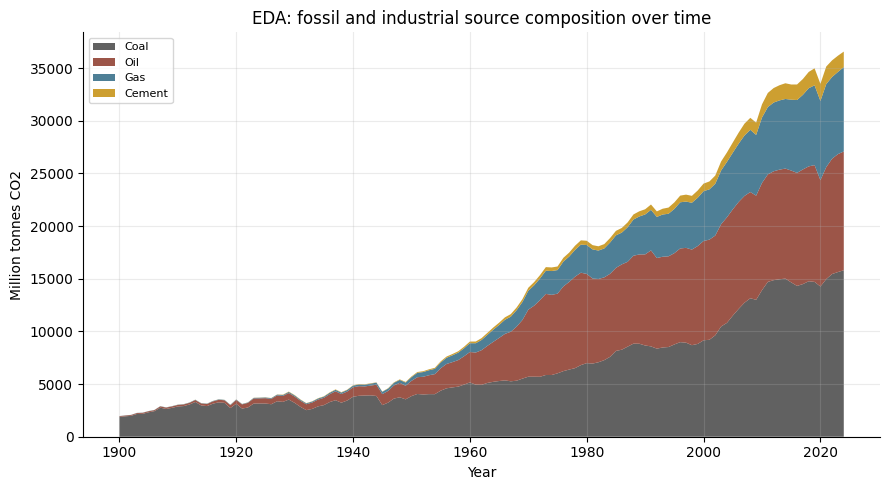

,source,co2_Mt,share_of_listed_sources_pct
0,coal_co2,"15,799.722",43.218
1,oil_co2,"11,276.420",30.845
2,gas_co2,"8,009.256",21.908
3,cement_co2,"1,472.579",4.028


In [6]:
source_cols = ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2']
source_by_year = countries.groupby('year')[source_cols].sum(min_count=1).reset_index()
source_recent = source_by_year[source_by_year['year'] >= 1900].copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.stackplot(
    source_recent['year'],
    [source_recent[c] for c in source_cols],
    labels=['Coal', 'Oil', 'Gas', 'Cement'],
    colors=['#4b4b4b', '#8f3d2e', '#356d88', '#c69214'],
    alpha=0.88,
)
ax.set_title('EDA: fossil and industrial source composition over time')
ax.set_xlabel('Year')
ax.set_ylabel('Million tonnes CO2')
ax.legend(loc='upper left', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'eda_source_composition.png', dpi=180)
plt.show()

latest_source_year = int(source_by_year.dropna(subset=source_cols, how='all')['year'].max())
latest_sources = source_by_year[source_by_year['year'] == latest_source_year][source_cols].T.reset_index()
latest_sources.columns = ['source', 'co2_Mt']
latest_sources['share_of_listed_sources_pct'] = 100 * latest_sources['co2_Mt'] / latest_sources['co2_Mt'].sum()
latest_sources.sort_values('co2_Mt', ascending=False)


,metric,country,value
9933,"total CO2, Mt",China,"12,289.037"
48007,"total CO2, Mt",United States,"4,904.120"
21762,"total CO2, Mt",India,"3,193.478"
38314,"total CO2, Mt",Russia,"1,780.524"
23812,"total CO2, Mt",Japan,961.867
21937,"total CO2, Mt",Indonesia,812.220
22662,"total CO2, Mt",Iran,792.631
40289,"total CO2, Mt",Saudi Arabia,692.133
37960,"CO2 per capita, t/person",Qatar,41.271
24865,"CO2 per capita, t/person",Kuwait,26.248


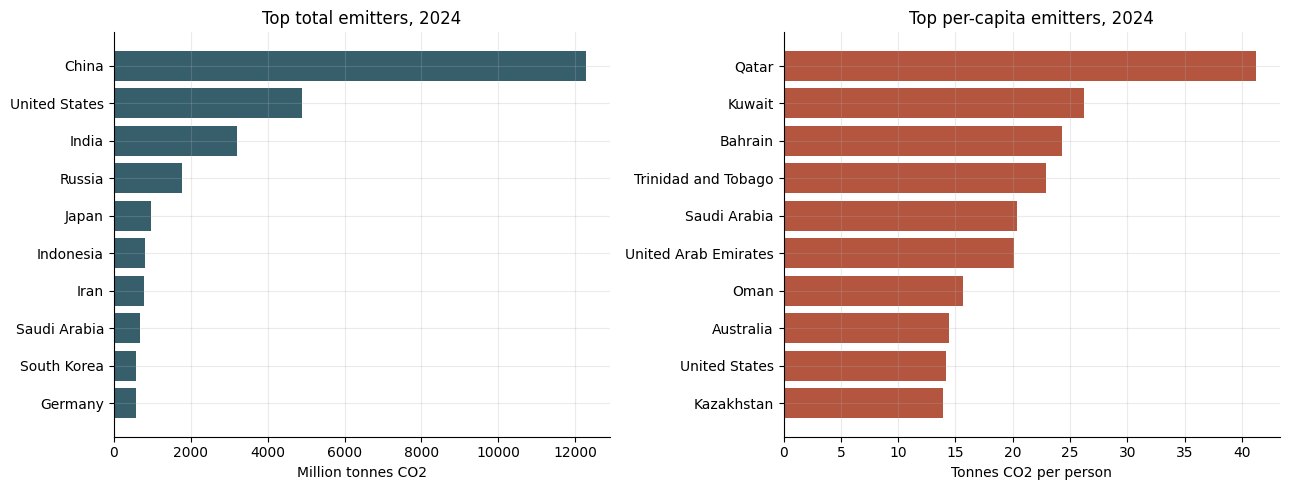

In [7]:
eda_latest_year = int(countries['year'].max())
latest_complete = countries[countries['year'] == eda_latest_year].copy()
latest_complete = latest_complete[latest_complete['population'].fillna(0) >= 1_000_000]

latest_rankings = pd.concat([
    latest_complete.dropna(subset=['co2']).nlargest(8, 'co2')[['country', 'co2']].rename(columns={'co2': 'value'}).assign(metric='total CO2, Mt'),
    latest_complete.dropna(subset=['co2_per_capita']).nlargest(8, 'co2_per_capita')[['country', 'co2_per_capita']].rename(columns={'co2_per_capita': 'value'}).assign(metric='CO2 per capita, t/person'),
    latest_complete.dropna(subset=['co2_per_unit_energy']).nlargest(8, 'co2_per_unit_energy')[['country', 'co2_per_unit_energy']].rename(columns={'co2_per_unit_energy': 'value'}).assign(metric='CO2 per unit energy, kg/kWh'),
])

display(latest_rankings[['metric', 'country', 'value']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
top_total = latest_complete.dropna(subset=['co2']).nlargest(10, 'co2').sort_values('co2')
axes[0].barh(top_total['country'], top_total['co2'], color='#365f6b')
axes[0].set_title(f'Top total emitters, {eda_latest_year}')
axes[0].set_xlabel('Million tonnes CO2')

top_pc = latest_complete.dropna(subset=['co2_per_capita']).nlargest(10, 'co2_per_capita').sort_values('co2_per_capita')
axes[1].barh(top_pc['country'], top_pc['co2_per_capita'], color='#b4553f')
axes[1].set_title(f'Top per-capita emitters, {eda_latest_year}')
axes[1].set_xlabel('Tonnes CO2 per person')

fig.tight_layout()
fig.savefig(FIGURES / 'eda_total_vs_percapita_rankings.png', dpi=180)
plt.show()


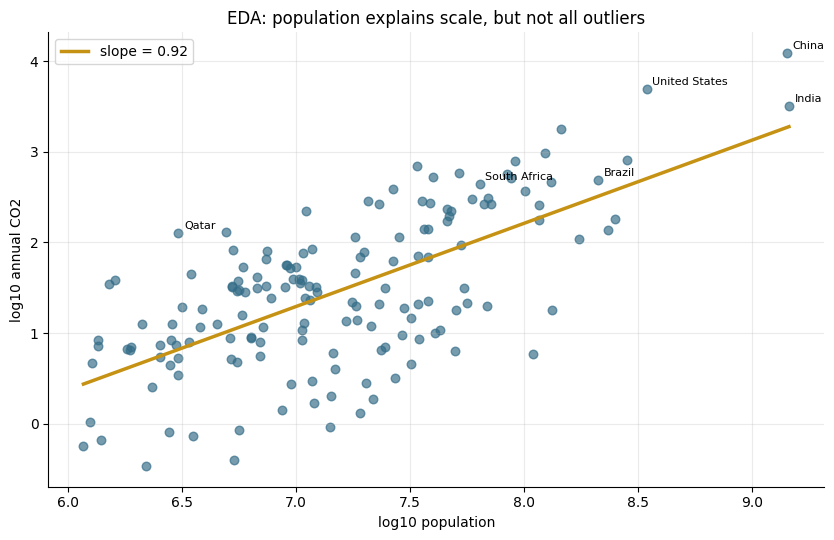

,outlier_type,country,population,co2,population_residual
37960,emits more than population predicts,Qatar,"3,048,429.000",125.812,1.279
24865,emits more than population predicts,Kuwait,"4,934,508.000",129.519,1.100
40289,emits more than population predicts,Saudi Arabia,"33,962,751.000",692.133,1.059
4514,emits more than population predicts,Bahrain,"1,607,059.000",39.003,1.026
47507,emits more than population predicts,United Arab Emirates,"11,027,135.000",221.988,1.014
45799,emits more than population predicts,Trinidad and Tobago,"1,507,778.000",34.576,0.999
12406,emits less than population predicts,Democratic Republic of Congo,"109,276,264.000",5.904,-1.475
8187,emits less than population predicts,Burundi,"14,047,788.000",0.917,-1.467
9227,emits less than population predicts,Central African Republic,"5,330,691.000",0.395,-1.446
42238,emits less than population predicts,Somalia,"19,009,155.000",1.319,-1.429


In [8]:
eda_latest_year = int(countries['year'].max())
scatter = countries[(countries['year'] == eda_latest_year)].dropna(subset=['population', 'co2']).copy()
scatter = scatter[(scatter['population'] >= 1_000_000) & (scatter['co2'] > 0)]
scatter['log_population'] = np.log10(scatter['population'])
scatter['log_co2'] = np.log10(scatter['co2'])

coef = np.polyfit(scatter['log_population'], scatter['log_co2'], deg=1)
scatter['predicted_log_co2'] = np.polyval(coef, scatter['log_population'])
scatter['population_residual'] = scatter['log_co2'] - scatter['predicted_log_co2']

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(scatter['log_population'], scatter['log_co2'], alpha=0.68, s=38, color='#356d88')
x_line = np.linspace(scatter['log_population'].min(), scatter['log_population'].max(), 100)
ax.plot(x_line, np.polyval(coef, x_line), color='#c69214', linewidth=2.5, label=f'slope = {coef[0]:.2f}')
for name in ['China', 'India', 'United States', 'Qatar', 'South Africa', 'Brazil']:
    row = scatter[scatter['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['log_population'].iloc[0], row['log_co2'].iloc[0]), fontsize=8, xytext=(4, 3), textcoords='offset points')
ax.set_title('EDA: population explains scale, but not all outliers')
ax.set_xlabel('log10 population')
ax.set_ylabel('log10 annual CO2')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'eda_population_vs_co2_residuals.png', dpi=180)
plt.show()

pd.concat([
    scatter.nlargest(6, 'population_residual').assign(outlier_type='emits more than population predicts'),
    scatter.nsmallest(6, 'population_residual').assign(outlier_type='emits less than population predicts'),
])[['outlier_type', 'country', 'population', 'co2', 'population_residual']]


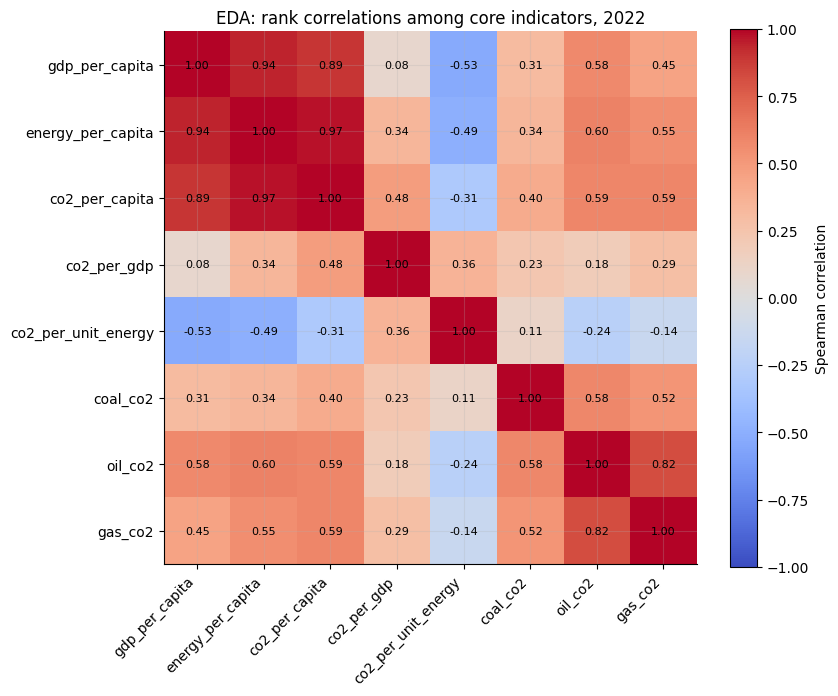

,gdp_per_capita,energy_per_capita,co2_per_capita,co2_per_gdp,co2_per_unit_energy,coal_co2,oil_co2,gas_co2
gdp_per_capita,1.000,0.942,0.891,0.083,-0.530,0.311,0.576,0.453
energy_per_capita,0.942,1.000,0.970,0.338,-0.495,0.339,0.605,0.547
co2_per_capita,0.891,0.970,1.000,0.481,-0.311,0.399,0.593,0.587
co2_per_gdp,0.083,0.338,0.481,1.000,0.356,0.231,0.182,0.287
co2_per_unit_energy,-0.530,-0.495,-0.311,0.356,1.000,0.110,-0.240,-0.145
coal_co2,0.311,0.339,0.399,0.231,0.110,1.000,0.582,0.516
oil_co2,0.576,0.605,0.593,0.182,-0.240,0.582,1.000,0.817
gas_co2,0.453,0.547,0.587,0.287,-0.145,0.516,0.817,1.000


In [9]:
corr_year = 2022
corr_cols = [
    'gdp', 'population', 'energy_per_capita', 'co2_per_capita',
    'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'oil_co2', 'gas_co2',
]
corr_df = countries[countries['year'] == corr_year].copy()
corr_df = corr_df[corr_df['population'].fillna(0) >= 1_000_000]
corr_df['gdp_per_capita'] = corr_df['gdp'] / corr_df['population']
corr_matrix_cols = ['gdp_per_capita', 'energy_per_capita', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'oil_co2', 'gas_co2']
corr_matrix = corr_df[corr_matrix_cols].corr(method='spearman')

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix_cols)))
ax.set_yticks(range(len(corr_matrix_cols)))
ax.set_xticklabels(corr_matrix_cols, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix_cols)
for i in range(len(corr_matrix_cols)):
    for j in range(len(corr_matrix_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Spearman correlation')
ax.set_title(f'EDA: rank correlations among core indicators, {corr_year}')
fig.tight_layout()
fig.savefig(FIGURES / 'eda_spearman_correlation_heatmap.png', dpi=180)
plt.show()

corr_matrix


### EDA Takeaway

The exploratory results motivate the formal hypotheses. Global total CO2 rises much faster than average per-capita emissions, source composition shifts across coal, oil, gas, and cement, and the country rankings change depending on whether we rank by total emissions, per-capita emissions, or energy carbon intensity. The log-population model confirms that scale matters, but the residuals show that population alone cannot explain national emissions. The Spearman heatmap points toward the later argument: energy use, fuel structure, and economic output are related but not interchangeable.


In [10]:
import math

def spearman_corr(x, y):
    return pd.Series(x).rank(method='average').corr(pd.Series(y).rank(method='average'))


def permutation_corr_test(x, y, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.array(x, copy=True, dtype=float)
    y = np.array(y, copy=True, dtype=float)
    observed = spearman_corr(x, y)
    count = 0
    for _ in range(n):
        if abs(spearman_corr(x, rng.permutation(y))) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def permutation_mean_test(a, b, n=5000, seed=1):
    rng = np.random.default_rng(seed)
    a = np.array(a, copy=True, dtype=float)
    b = np.array(b, copy=True, dtype=float)
    observed = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n):
        permuted = rng.permutation(pool)
        diff = permuted[:n_a].mean() - permuted[n_a:].mean()
        if abs(diff) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def normal_cdf(z):
    return 0.5 * (1 + math.erf(z / math.sqrt(2)))


def two_sided_p_from_z(z):
    return 2 * (1 - normal_cdf(abs(z)))


def fisher_z_corr_test(x, y):
    """Large-sample z-test for correlation after ranking if x/y are ranks."""
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)
    d = pd.concat([x, y], axis=1).dropna()
    r = d.iloc[:, 0].corr(d.iloc[:, 1])
    n = len(d)
    r_clip = np.clip(r, -0.999999, 0.999999)
    z = np.arctanh(r_clip) * np.sqrt(max(n - 3, 1))
    return r, z, two_sided_p_from_z(z), n


def one_sample_z_test(x, null_mean=0):
    x = pd.Series(x).dropna().astype(float).to_numpy()
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    z = (mean - null_mean) / se
    return {'mean': mean, 'null_mean': null_mean, 'z': z, 'p_value_two_sided': two_sided_p_from_z(z), 'n': len(x)}


def bootstrap_proportion_ci(indicator, n=5000, seed=101):
    rng = np.random.default_rng(seed)
    x = pd.Series(indicator).dropna().astype(bool).to_numpy()
    props = np.empty(n)
    for i in range(n):
        props[i] = rng.choice(x, size=len(x), replace=True).mean()
    return np.percentile(props, [2.5, 50, 97.5])


def two_sample_z_test(a, b):
    """Welch-style large-sample z-test for difference in means."""
    a = pd.Series(a).dropna().astype(float).to_numpy()
    b = pd.Series(b).dropna().astype(float).to_numpy()
    diff = a.mean() - b.mean()
    se = np.sqrt(a.var(ddof=1) / len(a) + b.var(ddof=1) / len(b))
    z = diff / se
    pooled_sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2))
    cohen_d = diff / pooled_sd
    return {'mean_a': a.mean(), 'mean_b': b.mean(), 'difference': diff, 'z': z, 'p_value': two_sided_p_from_z(z), 'cohen_d': cohen_d, 'n_a': len(a), 'n_b': len(b)}


def two_proportion_z_test(success_a, n_a, success_b, n_b):
    p_a = success_a / n_a
    p_b = success_b / n_b
    pooled = (success_a + success_b) / (n_a + n_b)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n_a + 1 / n_b))
    z = (p_a - p_b) / se
    return {'prop_a': p_a, 'prop_b': p_b, 'difference': p_a - p_b, 'z': z, 'p_value': two_sided_p_from_z(z), 'n_a': n_a, 'n_b': n_b}


def bh_adjust(p_values):
    """Benjamini-Hochberg false-discovery-rate adjustment."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.minimum.accumulate((ranked * n / np.arange(1, n + 1))[::-1])[::-1]
    adjusted = np.empty(n)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted


def ols_coefficient_table(X, y, feature_names):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    fitted = X_design @ beta
    residuals = y - fitted
    n, p = X_design.shape
    sigma2 = (residuals @ residuals) / (n - p)
    cov = sigma2 * np.linalg.inv(X_design.T @ X_design)
    se = np.sqrt(np.diag(cov))
    z = beta / se
    return pd.DataFrame({
        'term': ['intercept'] + list(feature_names),
        'coef': beta,
        'std_error': se,
        'z_stat': z,
        'p_value': [two_sided_p_from_z(v) for v in z],
    })


def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.arange(1, n + 1) @ x) / (n * x.sum()) - (n + 1) / n


def fit_ols(X, y, feature_names):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    fitted = X_design @ beta
    residuals = y - fitted
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return {
        'terms': ['intercept'] + list(feature_names),
        'beta': beta,
        'fitted': fitted,
        'residuals': residuals,
        'r2': 1 - ss_res / ss_tot,
        'rmse': np.sqrt(np.mean(residuals ** 2)),
    }


def bootstrap_ols_ci(X, y, feature_names, n=1000, seed=3):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    coefs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        coefs.append(fit_ols(X[idx], y[idx], feature_names)['beta'])
    return np.percentile(np.asarray(coefs), [2.5, 50, 97.5], axis=0)


def label_points(ax, data, names, x, y, fontsize=8, x_scale=1):
    for name in names:
        row = data[data['country'] == name]
        if not row.empty:
            ax.annotate(
                name,
                (row[x].iloc[0] * x_scale, row[y].iloc[0]),
                fontsize=fontsize,
                xytext=(4, 3),
                textcoords='offset points',
            )


## Methods

We use five statistical tools to check the main chart patterns:

- **Spearman correlation** tests whether two variables move together in rank order. This is more appropriate than relying only on linear correlation because country-level CO2 variables are skewed and contain outliers.
- **Permutation tests** estimate how surprising an observed relationship would be if labels or values were randomly rearranged under a null hypothesis.
- **Bootstrap confidence intervals** estimate uncertainty in the coal-intensity gap without assuming that country emissions follow a normal distribution.
- **Z-style tests** add explicit p-values for correlations, mean gaps, and proportions when large-sample assumptions are reasonable.
- **Effect sizes** such as Cohen's d report practical size, not only statistical significance.
- **OLS model comparison and coefficient tests** check whether adding energy use and coal share improves prediction beyond GDP alone. This is associational, not causal.
- **Concentration measures** such as top-emitter share, Lorenz curves, and Gini index summarize how unequal national emissions are.

These checks come before the hypothesis sections because they explain how the results are evaluated.


In [11]:
# Construct the high-coal vs low-coal comparison used to validate H2A.
h2_methods = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2_methods = h2_methods[(h2_methods['population'] >= 1_000_000) & (h2_methods['co2'] > 20)]
h2_methods['known_fossil_co2'] = h2_methods[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2_methods = h2_methods[h2_methods['known_fossil_co2'] > 0]
h2_methods['coal_share'] = h2_methods['coal_co2'] / h2_methods['known_fossil_co2']

high_coal = h2_methods[h2_methods['coal_share'] >= 0.5]['co2_per_unit_energy'].to_numpy()
low_coal = h2_methods[h2_methods['coal_share'] < 0.2]['co2_per_unit_energy'].to_numpy()
observed_gap = high_coal.mean() - low_coal.mean()

print(f'High-coal countries: n={len(high_coal)}, mean={high_coal.mean():.3f} kg CO2/kWh')
print(f'Low-coal countries: n={len(low_coal)}, mean={low_coal.mean():.3f} kg CO2/kWh')
print(f'Observed mean gap: {observed_gap:.3f} kg CO2/kWh')


High-coal countries: n=8, mean=0.274 kg CO2/kWh
Low-coal countries: n=39, mean=0.168 kg CO2/kWh
Observed mean gap: 0.106 kg CO2/kWh


### Permutation Test

The null hypothesis is that coal-heavy and low-coal labels are exchangeable. If coal share does not matter, randomly shuffling labels should often produce a gap as large as the observed gap. The p-value below is the fraction of shuffled-label simulations that produce an absolute mean gap at least as large as the real one.


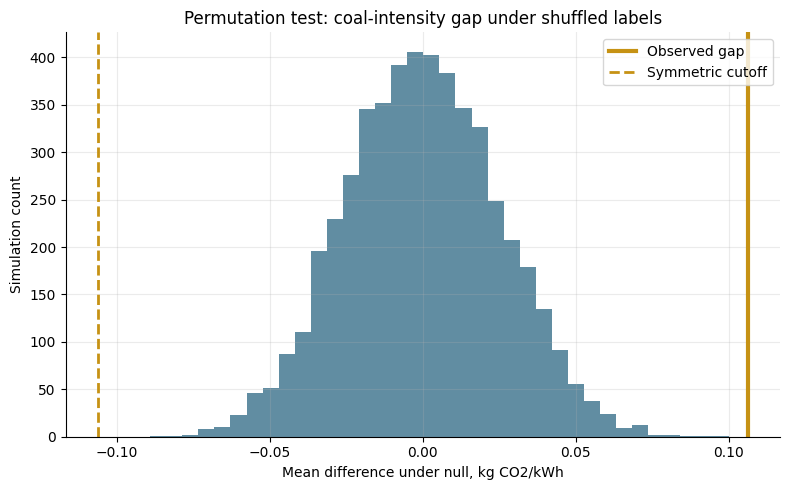

,observed_gap,permutation_p_value,simulations
0,0.106,0.000,5000


In [12]:
rng = np.random.default_rng(328)
pool = np.concatenate([high_coal, low_coal])
perm_diffs = []
for _ in range(5000):
    permuted = rng.permutation(pool)
    perm_diffs.append(permuted[:len(high_coal)].mean() - permuted[len(high_coal):].mean())
perm_diffs = np.array(perm_diffs)
perm_p = (np.sum(np.abs(perm_diffs) >= abs(observed_gap)) + 1) / (len(perm_diffs) + 1)

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=36, color='#356d88', alpha=0.78)
ax.axvline(observed_gap, color='#c69214', linewidth=3, label='Observed gap')
ax.axvline(-observed_gap, color='#c69214', linewidth=2, linestyle='--', label='Symmetric cutoff')
ax.set_title('Permutation test: coal-intensity gap under shuffled labels')
ax.set_xlabel('Mean difference under null, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_permutation_test.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'permutation_p_value': perm_p,
    'simulations': len(perm_diffs),
}])

### Bootstrap Confidence Interval

The bootstrap resamples high-coal and low-coal countries with replacement and recomputes the mean gap. This gives uncertainty bounds for the estimated coal-intensity difference without assuming a normal population distribution.


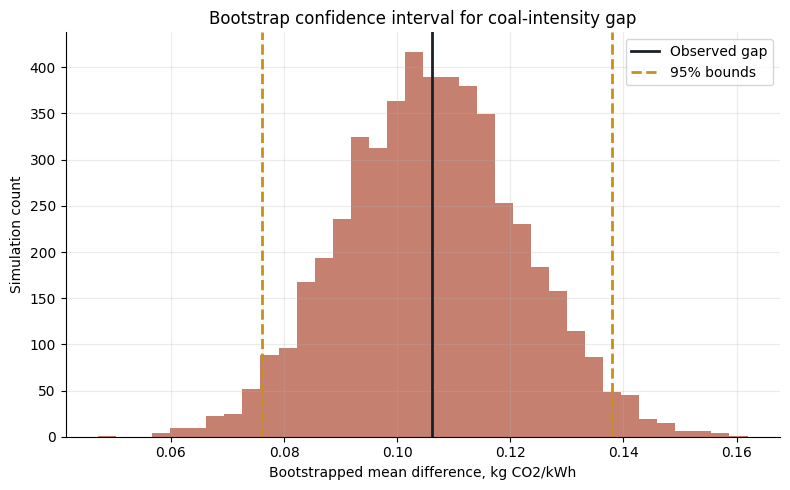

,observed_gap,ci_lower_2_5_pct,ci_upper_97_5_pct
0,0.106,0.076,0.138


In [13]:
boot_diffs = []
for _ in range(5000):
    boot_high = rng.choice(high_coal, size=len(high_coal), replace=True)
    boot_low = rng.choice(low_coal, size=len(low_coal), replace=True)
    boot_diffs.append(boot_high.mean() - boot_low.mean())
boot_diffs = np.array(boot_diffs)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=36, color='#b4553f', alpha=0.75)
ax.axvline(observed_gap, color='#192026', linewidth=2, label='Observed gap')
ax.axvline(ci_low, color='#c69214', linewidth=2, linestyle='--', label='95% bounds')
ax.axvline(ci_high, color='#c69214', linewidth=2, linestyle='--')
ax.set_title('Bootstrap confidence interval for coal-intensity gap')
ax.set_xlabel('Bootstrapped mean difference, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_bootstrap_bounds.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'ci_lower_2_5_pct': ci_low,
    'ci_upper_97_5_pct': ci_high,
}])

### Central Limit Theorem Check

The distribution of country CO2 per capita is highly skewed, but repeated sample means are smoother and more concentrated around the population mean. This is a sanity check for why averages and confidence intervals can still be informative, while also reminding us that outliers must be handled carefully.


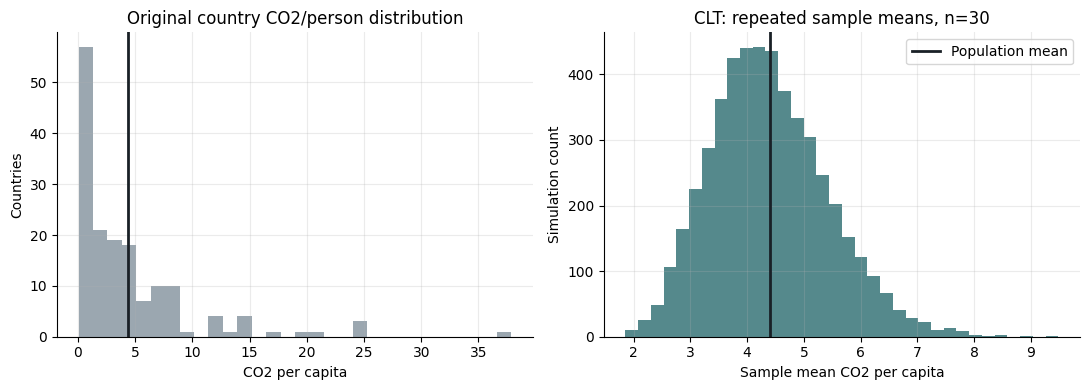

,population_mean,mean_of_sample_means,standard_error_simulated,sample_size
0,4.395,4.390,1.031,30


In [14]:
co2pc_2022 = countries[(countries['year'] == 2022) & (countries['population'] >= 1_000_000)]['co2_per_capita'].dropna().to_numpy()
sample_size = 30
sample_means = np.array([
    rng.choice(co2pc_2022, size=sample_size, replace=True).mean()
    for _ in range(5000)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(co2pc_2022, bins=30, color='#8a98a3', alpha=0.85)
axes[0].axvline(co2pc_2022.mean(), color='#192026', linewidth=2)
axes[0].set_title('Original country CO2/person distribution')
axes[0].set_xlabel('CO2 per capita')
axes[0].set_ylabel('Countries')

axes[1].hist(sample_means, bins=34, color='#2f6f73', alpha=0.82)
axes[1].axvline(co2pc_2022.mean(), color='#192026', linewidth=2, label='Population mean')
axes[1].set_title('CLT: repeated sample means, n=30')
axes[1].set_xlabel('Sample mean CO2 per capita')
axes[1].set_ylabel('Simulation count')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'methods_clt_sample_means.png', dpi=180)
plt.show()

pd.DataFrame([{
    'population_mean': co2pc_2022.mean(),
    'mean_of_sample_means': sample_means.mean(),
    'standard_error_simulated': sample_means.std(ddof=1),
    'sample_size': sample_size,
}])

### K-means Clustering

K-means groups countries using standardized 2022 values of log GDP per capita, log energy per capita, CO2 per capita, and CO2 per GDP. The clusters are not moral categories and not causal proof; they are a compact way to show that countries occupy different emissions profiles.


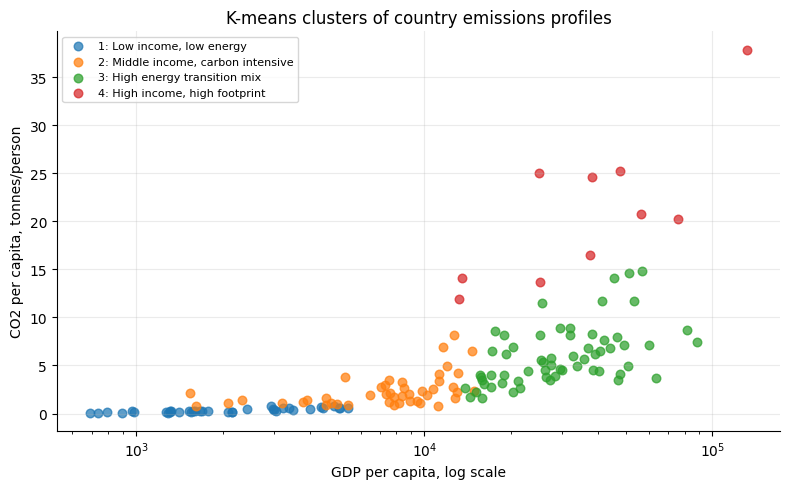

,cluster,cluster_name,countries,avg_gdp_per_capita,avg_energy_per_capita,avg_co2_per_capita,avg_co2_per_gdp
0,1,"Low income, low energy",37,"2,391.718","1,407.265",0.332,0.142
1,2,"Middle income, carbon intensive",45,"8,138.788","9,828.472",2.376,0.326
2,3,High energy transition mix,61,"32,741.217","36,964.033",6.025,0.200
3,4,"High income, high footprint",10,"46,526.598","101,628.520",21.006,0.603


In [15]:
cluster_df = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'energy_per_capita', 'co2_per_capita', 'co2_per_gdp']
).copy()
cluster_df = cluster_df[cluster_df['population'] >= 1_000_000]
cluster_df['gdp_per_capita'] = cluster_df['gdp'] / cluster_df['population']

features = np.column_stack([
    np.log10(cluster_df['gdp_per_capita']),
    np.log10(cluster_df['energy_per_capita']),
    cluster_df['co2_per_capita'],
    cluster_df['co2_per_gdp'],
])
z = (features - features.mean(axis=0)) / features.std(axis=0)

k = 4
order = np.argsort(z[:, 0])
centroids = z[order[np.linspace(0, len(order) - 1, k, dtype=int)]].copy()
labels = np.zeros(len(z), dtype=int)
for _ in range(100):
    distances = ((z[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    new_labels = distances.argmin(axis=1)
    if np.array_equal(labels, new_labels):
        break
    labels = new_labels
    for group in range(k):
        if np.any(labels == group):
            centroids[group] = z[labels == group].mean(axis=0)

cluster_df['cluster_raw'] = labels
ranked = cluster_df.groupby('cluster_raw')['gdp_per_capita'].mean().sort_values().index.tolist()
cluster_df['cluster'] = cluster_df['cluster_raw'].map({raw: idx for idx, raw in enumerate(ranked, start=1)})
cluster_names = {
    1: 'Low income, low energy',
    2: 'Middle income, carbon intensive',
    3: 'High energy transition mix',
    4: 'High income, high footprint',
}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

fig, ax = plt.subplots()
for cluster_id, group in cluster_df.groupby('cluster'):
    ax.scatter(
        group['gdp_per_capita'],
        group['co2_per_capita'],
        s=38,
        alpha=0.72,
        label=f'{cluster_id}: {cluster_names[cluster_id]}',
    )
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('K-means clusters of country emissions profiles')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'methods_kmeans_clusters.png', dpi=180)
plt.show()

cluster_summary = cluster_df.groupby(['cluster', 'cluster_name']).agg(
    countries=('country', 'count'),
    avg_gdp_per_capita=('gdp_per_capita', 'mean'),
    avg_energy_per_capita=('energy_per_capita', 'mean'),
    avg_co2_per_capita=('co2_per_capita', 'mean'),
    avg_co2_per_gdp=('co2_per_gdp', 'mean'),
).reset_index()
cluster_summary

### Methods Takeaway

The statistical checks support the main results. The coal-intensity gap is unlikely under random label shuffling, the bootstrap interval stays above zero, the CLT check explains why sample means are useful despite skew, and k-means shows that countries fall into distinct emissions profiles rather than a simple rich/poor binary.


## Global Baseline: Emissions Are Concentrated

Before testing country-level hypotheses, we need the shape of the problem. If emissions were evenly distributed across countries, a single average would be a tolerable summary. They are not.

**Baseline claim:** national emissions responsibility is highly concentrated, so total emissions, per-capita emissions, and cumulative emissions answer different questions.


In [16]:
latest_year = int(countries['year'].max())
latest = countries[(countries['year'] == latest_year) & countries['co2'].notna()].copy()
latest = latest[latest['co2'] > 0]
latest['annual_share_calc'] = 100 * latest['co2'] / latest['co2'].sum()

top10 = latest.nlargest(10, 'co2').copy()
top10_share = top10['co2'].sum() / latest['co2'].sum() * 100
annual_gini = gini(latest['co2'])

cum_latest = countries[(countries['year'] == latest_year) & countries['cumulative_co2'].notna()].copy()
cum_latest = cum_latest[cum_latest['cumulative_co2'] > 0]
cum_top10_share = cum_latest.nlargest(10, 'cumulative_co2')['cumulative_co2'].sum() / cum_latest['cumulative_co2'].sum() * 100
cum_gini = gini(cum_latest['cumulative_co2'])

summary = pd.DataFrame([{
    'year': latest_year,
    'countries_with_positive_annual_co2': len(latest),
    'top10_share_of_annual_co2_pct': top10_share,
    'annual_co2_gini': annual_gini,
    'top10_share_of_cumulative_co2_pct': cum_top10_share,
    'cumulative_co2_gini': cum_gini,
}])
display(summary)

top10[['country', 'co2', 'annual_share_calc', 'co2_per_capita']].rename(columns={
    'co2': 'annual_co2_Mt',
    'annual_share_calc': 'share_of_world_pct',
    'co2_per_capita': 'co2_per_capita_t',
})


,year,countries_with_positive_annual_co2,top10_share_of_annual_co2_pct,annual_co2_gini,top10_share_of_cumulative_co2_pct,cumulative_co2_gini
0,2024,213,71.079,0.894,69.914,0.891


,country,annual_co2_Mt,share_of_world_pct,co2_per_capita_t
9933,China,"12,289.037",32.860,8.658
48007,United States,"4,904.120",13.113,14.197
21762,India,"3,193.478",8.539,2.201
38314,Russia,"1,780.524",4.761,12.295
23812,Japan,961.867,2.572,7.772
21937,Indonesia,812.220,2.172,2.865
22662,Iran,792.631,2.119,8.656
40289,Saudi Arabia,692.133,1.851,20.379
43038,South Korea,583.679,1.561,11.286
18319,Germany,572.319,1.530,6.769


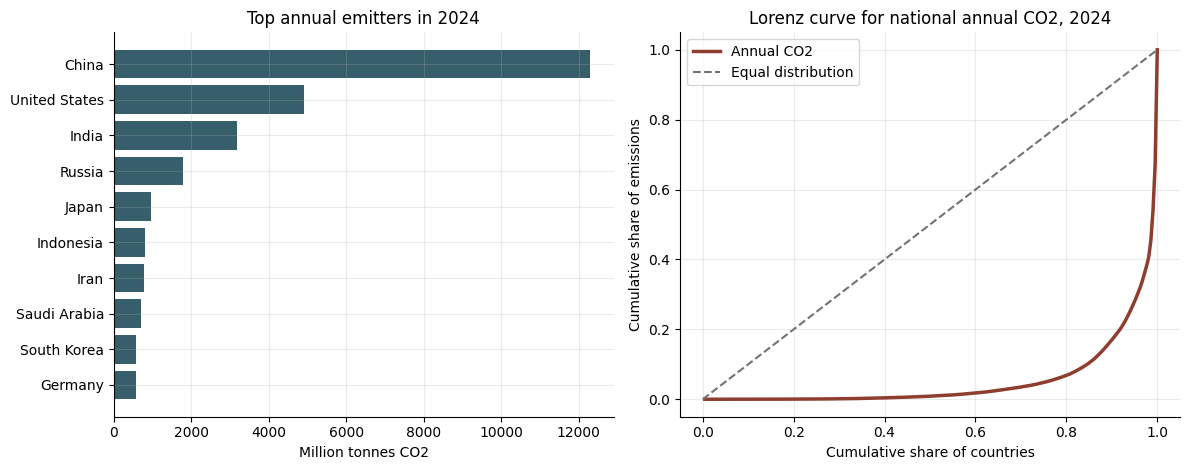

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

plot_top = top10.sort_values('co2')
axes[0].barh(plot_top['country'], plot_top['co2'], color='#365f6b')
axes[0].set_title(f'Top annual emitters in {latest_year}')
axes[0].set_xlabel('Million tonnes CO2')

x = np.sort(latest['co2'].to_numpy())
cum_countries = np.arange(1, len(x) + 1) / len(x)
cum_emissions = np.cumsum(x) / x.sum()
axes[1].plot(cum_countries, cum_emissions, color='#8f3d2e', linewidth=2.5, label='Annual CO2')
axes[1].plot([0, 1], [0, 1], color='0.45', linestyle='--', label='Equal distribution')
axes[1].set_title(f'Lorenz curve for national annual CO2, {latest_year}')
axes[1].set_xlabel('Cumulative share of countries')
axes[1].set_ylabel('Cumulative share of emissions')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'baseline_concentration_top_emitters_lorenz.png', dpi=180)
plt.show()


### Baseline Interpretation

The baseline supports treating emissions as a concentration problem. In the latest territorial CO2 year, the ten largest emitters account for most reported annual emissions, and the Lorenz curve is far from the equality line. Smaller countries still matter for per-capita and consumption-based responsibility, but the global mitigation arithmetic is dominated by a relatively small set of large national systems.


## Results and Interpretation

The hypotheses below move from simpler foundations to less obvious claims. H1 and H2 are intentionally basic building blocks: wealth and fossil-fuel dependence clearly matter, but they do not fully explain emissions outcomes. H3, H4, H5, and H6 add the more interesting layers: accounting responsibility, growth-emissions decoupling, land-use change, and the difference between current mitigation priority and historical responsibility.


## Hypothesis 1: Economy

**H1A:** Higher GDP per capita is associated with higher CO2 per capita.

**H1B:** GDP per capita alone does not reliably predict CO2 per GDP; energy mix and economic structure explain variation better.


In [18]:
h1 = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'co2_per_capita', 'co2_per_gdp']
).copy()
h1 = h1[h1['population'] >= 1_000_000]
h1['gdp_per_capita'] = h1['gdp'] / h1['population']

stats_rows = []
for x, y, label in [
    ('gdp_per_capita', 'co2_per_capita', 'GDP per capita vs CO2 per capita'),
    ('gdp_per_capita', 'co2_per_gdp', 'GDP per capita vs CO2 per GDP'),
]:
    d = h1[[x, y]].dropna()
    r, p = permutation_corr_test(d[x], d[y], n=1000)
    stats_rows.append({'comparison': label, 'spearman_r': round(r, 3), 'permutation_p': round(p, 4), 'n': len(d)})

pd.DataFrame(stats_rows)

,comparison,spearman_r,permutation_p,n
0,GDP per capita vs CO2 per capita,0.891,0.001,153
1,GDP per capita vs CO2 per GDP,0.083,0.301,153


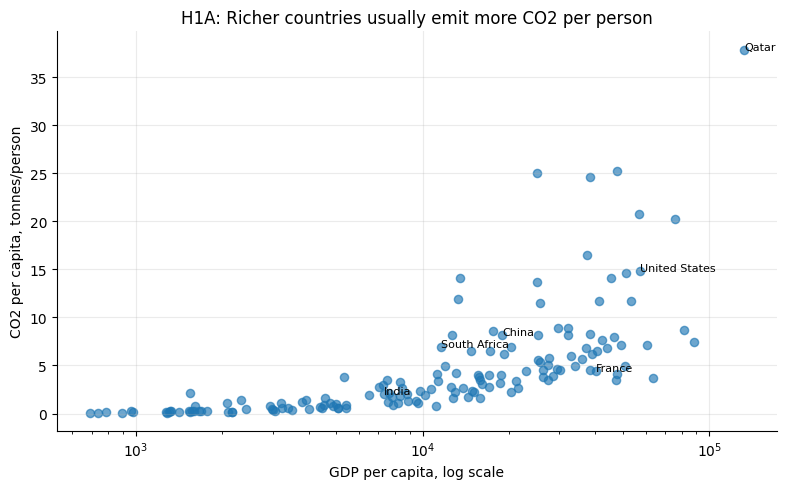

In [19]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_capita'], alpha=0.65, s=35)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H1A: Richer countries usually emit more CO2 per person')

for name in ['United States', 'China', 'India', 'Qatar', 'France', 'South Africa']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1a_gdp_vs_co2_per_capita.png', dpi=180)
plt.show()

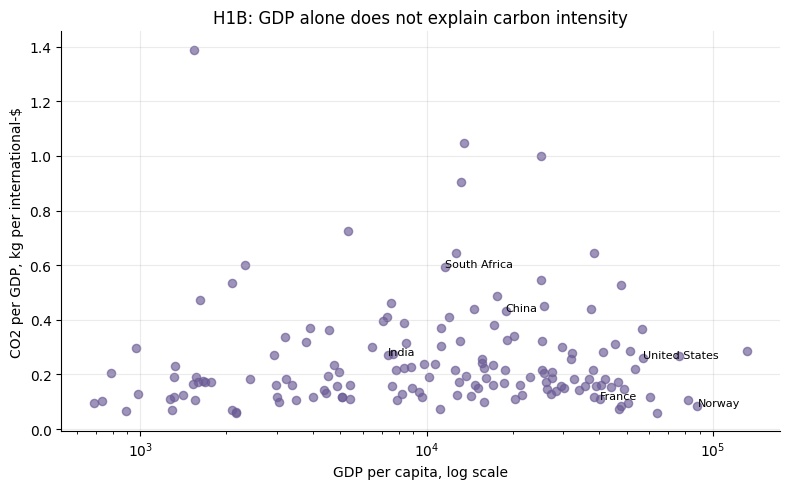

In [20]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_gdp'], alpha=0.65, s=35, color='#6b5b95')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per GDP, kg per international-$')
ax.set_title('H1B: GDP alone does not explain carbon intensity')

for name in ['China', 'India', 'South Africa', 'United States', 'France', 'Norway']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_gdp'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1b_gdp_vs_co2_per_gdp.png', dpi=180)
plt.show()

In [21]:
# Residual check: which countries are unusually carbon-intensive for their income level?
model_h1 = h1[['country', 'gdp_per_capita', 'co2_per_gdp']].dropna().copy()
X_h1 = np.log10(model_h1[['gdp_per_capita']].to_numpy())
y_h1 = model_h1['co2_per_gdp'].to_numpy()
fit_h1 = fit_ols(X_h1, y_h1, ['log10_gdp_per_capita'])
model_h1['predicted_co2_per_gdp'] = fit_h1['fitted']
model_h1['residual'] = model_h1['co2_per_gdp'] - model_h1['predicted_co2_per_gdp']

pd.concat([
    model_h1.nlargest(8, 'residual').assign(outlier_type='higher intensity than income predicts'),
    model_h1.nsmallest(8, 'residual').assign(outlier_type='lower intensity than income predicts'),
])[['outlier_type', 'country', 'gdp_per_capita', 'co2_per_gdp', 'predicted_co2_per_gdp', 'residual']]


,outlier_type,country,gdp_per_capita,co2_per_gdp,predicted_co2_per_gdp,residual
34458,higher intensity than income predicts,North Korea,"1,537.813",1.390,0.240,1.150
46426,higher intensity than income predicts,Turkmenistan,"13,485.517",1.047,0.251,0.796
45797,higher intensity than income predicts,Trinidad and Tobago,"25,077.082",0.999,0.254,0.745
30560,higher intensity than income predicts,Mongolia,"13,233.687",0.903,0.251,0.652
49159,higher intensity than income predicts,Venezuela,"5,305.426",0.724,0.246,0.478
26477,higher intensity than income predicts,Libya,"12,658.771",0.645,0.250,0.395
4512,higher intensity than income predicts,Bahrain,"38,324.938",0.644,0.256,0.388
44468,higher intensity than income predicts,Syria,"2,330.725",0.600,0.242,0.358
44293,lower intensity than income predicts,Switzerland,"63,623.009",0.059,0.258,-0.199
44118,lower intensity than income predicts,Sweden,"47,124.891",0.074,0.257,-0.183


### H1 Robustness: Uncertainty and Income Groups

The H1 scatterplots show the pattern visually. To make the claim more statistical, we add two checks: bootstrap confidence intervals for the Spearman correlations, and GDP-per-capita quartile comparisons. This asks whether the income-emissions relationship is stable across resampling and whether richer groups differ in both footprint and carbon intensity.


In [22]:
rng = np.random.default_rng(110)
boot_rows = []
for x, y, label in [
    ('gdp_per_capita', 'co2_per_capita', 'GDP/person vs CO2/person'),
    ('gdp_per_capita', 'co2_per_gdp', 'GDP/person vs CO2/GDP'),
]:
    d = h1[[x, y]].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    boot = []
    for _ in range(4000):
        idx = rng.integers(0, len(d), len(d))
        boot.append(spearman_corr(d.loc[idx, x], d.loc[idx, y]))
    lo, med, hi = np.percentile(boot, [2.5, 50, 97.5])
    boot_rows.append({'comparison': label, 'bootstrap_median_r': med, 'ci_2_5': lo, 'ci_97_5': hi, 'n': len(d)})

h1_bootstrap = pd.DataFrame(boot_rows)
h1_bootstrap


,comparison,bootstrap_median_r,ci_2_5,ci_97_5,n
0,GDP/person vs CO2/person,0.889,0.840,0.922,153
1,GDP/person vs CO2/GDP,0.083,-0.094,0.255,153


,income_quartile,countries,median_gdp_per_capita,median_co2_per_capita,median_co2_per_gdp,mean_co2_per_capita
0,Q1 lowest GDP/person,39,"1,684.669",0.301,0.164,0.470
1,Q2,38,"7,854.845",1.902,0.225,2.210
2,Q3,38,"18,073.752",4.023,0.210,5.653
3,Q4 highest GDP/person,38,"41,670.790",7.330,0.176,9.991


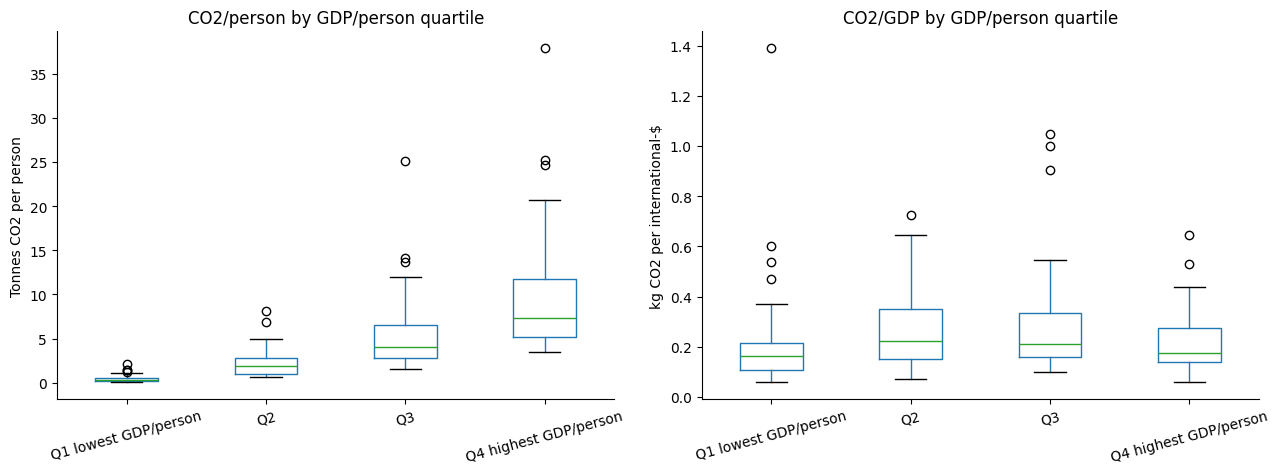

In [23]:
h1_groups = h1.copy()
h1_groups['income_quartile'] = pd.qcut(
    h1_groups['gdp_per_capita'],
    q=4,
    labels=['Q1 lowest GDP/person', 'Q2', 'Q3', 'Q4 highest GDP/person']
)

quartile_summary = h1_groups.groupby('income_quartile', observed=False).agg(
    countries=('country', 'count'),
    median_gdp_per_capita=('gdp_per_capita', 'median'),
    median_co2_per_capita=('co2_per_capita', 'median'),
    median_co2_per_gdp=('co2_per_gdp', 'median'),
    mean_co2_per_capita=('co2_per_capita', 'mean'),
).reset_index()
display(quartile_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
h1_groups.boxplot(column='co2_per_capita', by='income_quartile', ax=axes[0], grid=False, rot=15)
axes[0].set_title('CO2/person by GDP/person quartile')
axes[0].set_xlabel('')
axes[0].set_ylabel('Tonnes CO2 per person')

h1_groups.boxplot(column='co2_per_gdp', by='income_quartile', ax=axes[1], grid=False, rot=15)
axes[1].set_title('CO2/GDP by GDP/person quartile')
axes[1].set_xlabel('')
axes[1].set_ylabel('kg CO2 per international-$')
fig.suptitle('')
fig.tight_layout()
fig.savefig(FIGURES / 'h1_income_quartile_boxplots.png', dpi=180)
plt.show()


### H1 Formal Test Summary

This table turns the economy section into explicit statistical decisions. Fisher-z tests are applied to rank correlations, while large-sample z-tests compare the highest and lowest GDP-per-capita quartiles. P-values are also adjusted with Benjamini-Hochberg correction because multiple related tests are reported.


In [24]:
h1_q1 = h1_groups[h1_groups['income_quartile'] == 'Q1 lowest GDP/person']
h1_q4 = h1_groups[h1_groups['income_quartile'] == 'Q4 highest GDP/person']

corr_pc = fisher_z_corr_test(h1['gdp_per_capita'].rank(), h1['co2_per_capita'].rank())
corr_intensity = fisher_z_corr_test(h1['gdp_per_capita'].rank(), h1['co2_per_gdp'].rank())
z_pc_gap = two_sample_z_test(h1_q4['co2_per_capita'], h1_q1['co2_per_capita'])
z_intensity_gap = two_sample_z_test(h1_q4['co2_per_gdp'], h1_q1['co2_per_gdp'])

h1_tests = pd.DataFrame([
    {
        'test': 'Fisher-z rank correlation',
        'question': 'Does GDP/person rank with CO2/person?',
        'effect': corr_pc[0],
        'z_stat': corr_pc[1],
        'p_value': corr_pc[2],
        'n': corr_pc[3],
        'decision_at_0_05': 'reject null: positive association' if corr_pc[2] < 0.05 else 'fail to reject',
    },
    {
        'test': 'Fisher-z rank correlation',
        'question': 'Does GDP/person rank with CO2/GDP?',
        'effect': corr_intensity[0],
        'z_stat': corr_intensity[1],
        'p_value': corr_intensity[2],
        'n': corr_intensity[3],
        'decision_at_0_05': 'reject null: association' if corr_intensity[2] < 0.05 else 'fail to reject',
    },
    {
        'test': 'Two-sample z-test, Q4 vs Q1',
        'question': 'Do richest-quartile countries emit more CO2/person than poorest-quartile countries?',
        'effect': z_pc_gap['difference'],
        'z_stat': z_pc_gap['z'],
        'p_value': z_pc_gap['p_value'],
        'n': z_pc_gap['n_a'] + z_pc_gap['n_b'],
        'decision_at_0_05': 'reject null: mean gap exists' if z_pc_gap['p_value'] < 0.05 else 'fail to reject',
    },
    {
        'test': 'Two-sample z-test, Q4 vs Q1',
        'question': 'Do richest-quartile countries have higher CO2/GDP than poorest-quartile countries?',
        'effect': z_intensity_gap['difference'],
        'z_stat': z_intensity_gap['z'],
        'p_value': z_intensity_gap['p_value'],
        'n': z_intensity_gap['n_a'] + z_intensity_gap['n_b'],
        'decision_at_0_05': 'reject null: mean gap exists' if z_intensity_gap['p_value'] < 0.05 else 'fail to reject',
    },
])
h1_tests['bh_adjusted_p'] = bh_adjust(h1_tests['p_value'])
h1_tests


,test,question,effect,z_stat,p_value,n,decision_at_0_05,bh_adjusted_p
0,Fisher-z rank correlation,Does GDP/person rank with CO2/person?,0.891,17.474,0.000,153,reject null: positive association,0.000
1,Fisher-z rank correlation,Does GDP/person rank with CO2/GDP?,0.083,1.025,0.306,153,fail to reject,0.407
2,"Two-sample z-test, Q4 vs Q1",Do richest-quartile countries emit more CO2/pe...,9.522,7.929,0.000,77,reject null: mean gap exists,0.000
3,"Two-sample z-test, Q4 vs Q1",Do richest-quartile countries have higher CO2/...,-0.009,-0.203,0.839,77,fail to reject,0.839


### Interpretation: Economy

The economy section supports H1A strongly. GDP per capita and CO2 per capita have a large positive rank relationship, and the Fisher-z test rejects the null of no rank association. The bootstrap interval gives the same message without relying on a single point estimate. The income-quartile boxplots and z-test add a practical comparison: the richest GDP-per-capita quartile has much higher average CO2 per person than the lowest quartile.

H1B is more nuanced. GDP per capita is much weaker for explaining CO2 per GDP than CO2 per person. The residual table makes the point concrete: some countries produce much more CO2 per dollar of output than their income level predicts, while service-heavy or cleaner-electricity economies often sit below the income-only expectation. The statistical result and the outlier table therefore agree: economic development increases energy-consuming capacity, but GDP alone does not determine how carbon-intensive an economy is.


## Hypothesis 2: Energy Mix

**H2A:** Coal-heavy countries have higher CO2 emissions intensity.

**H2B:** Energy use per capita strongly predicts CO2 per capita, and adding energy demand plus coal share should outperform a GDP-only model.


In [25]:
h2 = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2 = h2[(h2['population'] >= 1_000_000) & (h2['co2'] > 20)]
h2['known_fossil_co2'] = h2[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2 = h2[h2['known_fossil_co2'] > 0]
h2['coal_share'] = h2['coal_co2'] / h2['known_fossil_co2']

high_coal = h2[h2['coal_share'] >= 0.5]['co2_per_unit_energy'].dropna()
low_coal = h2[h2['coal_share'] < 0.2]['co2_per_unit_energy'].dropna()
diff, p = permutation_mean_test(high_coal, low_coal, n=2000)

pd.DataFrame([
    {'group': 'coal share >= 50%', 'n': len(high_coal), 'mean_co2_per_unit_energy': high_coal.mean()},
    {'group': 'coal share < 20%', 'n': len(low_coal), 'mean_co2_per_unit_energy': low_coal.mean()},
    {'group': 'difference and p-value', 'n': '', 'mean_co2_per_unit_energy': f'diff={diff:.3f}, p={p:.4f}'},
])

,group,n,mean_co2_per_unit_energy
0,coal share >= 50%,8,0.274
1,coal share < 20%,39,0.168
2,difference and p-value,,"diff=0.106, p=0.0005"


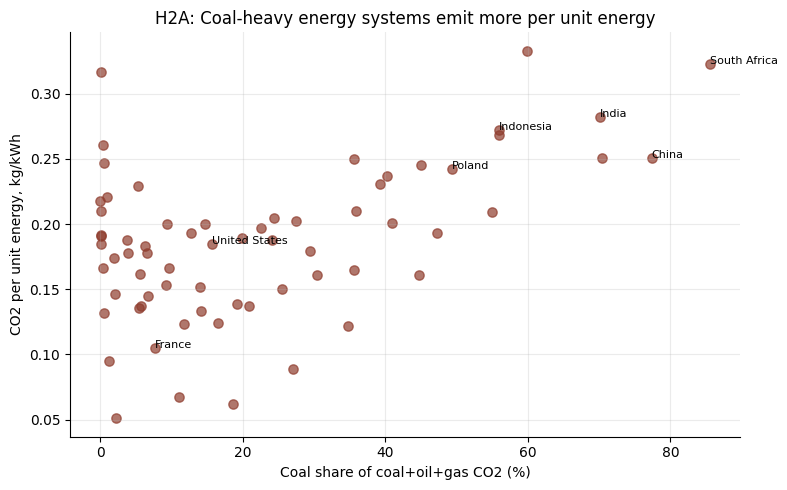

In [26]:
fig, ax = plt.subplots()
ax.scatter(h2['coal_share'] * 100, h2['co2_per_unit_energy'], alpha=0.7, s=45, color='#8f3d2e')
ax.set_xlabel('Coal share of coal+oil+gas CO2 (%)')
ax.set_ylabel('CO2 per unit energy, kg/kWh')
ax.set_title('H2A: Coal-heavy energy systems emit more per unit energy')

for name in ['South Africa', 'China', 'India', 'Indonesia', 'Poland', 'United States', 'France']:
    row = h2[h2['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['coal_share'].iloc[0] * 100, row['co2_per_unit_energy'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2a_coal_share_vs_energy_intensity.png', dpi=180)
plt.show()

Spearman r = 0.970, permutation p = 0.0010, n = 159


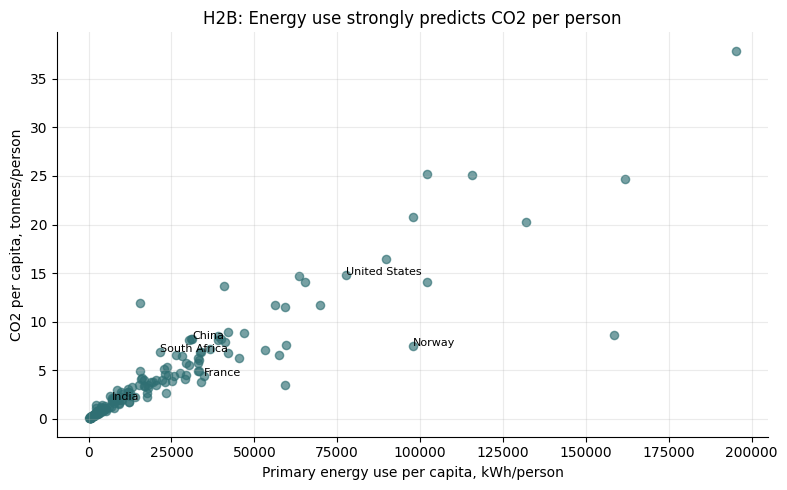

In [27]:
h2b = countries[countries['year'] == 2022].dropna(
    subset=['energy_per_capita', 'co2_per_capita', 'population']
).copy()
h2b = h2b[h2b['population'] >= 1_000_000]

r, p = permutation_corr_test(h2b['energy_per_capita'], h2b['co2_per_capita'], n=1000)
print(f'Spearman r = {r:.3f}, permutation p = {p:.4f}, n = {len(h2b)}')

fig, ax = plt.subplots()
ax.scatter(h2b['energy_per_capita'], h2b['co2_per_capita'], alpha=0.65, s=35, color='#2f6f73')
ax.set_xlabel('Primary energy use per capita, kWh/person')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H2B: Energy use strongly predicts CO2 per person')

for name in ['United States', 'China', 'India', 'Norway', 'France', 'South Africa']:
    row = h2b[h2b['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['energy_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2b_energy_vs_co2_per_capita.png', dpi=180)
plt.show()

### H2 Formal Test Summary

H2 uses three statistical checks: a z-test for the high-coal vs low-coal energy-intensity gap, a Fisher-z test for the energy-use/CO2-per-capita association, and a Cohen's-d effect size for the coal gap. The permutation test remains useful because it avoids distributional assumptions; the z-test gives a conventional p-value companion.


In [28]:
coal_z = two_sample_z_test(high_coal, low_coal)
energy_corr_z = fisher_z_corr_test(h2b['energy_per_capita'].rank(), h2b['co2_per_capita'].rank())

h2_tests = pd.DataFrame([
    {
        'test': 'Two-sample z-test',
        'question': 'Is energy carbon intensity higher in high-coal than low-coal countries?',
        'effect': coal_z['difference'],
        'effect_unit': 'kg CO2/kWh',
        'z_stat': coal_z['z'],
        'p_value': coal_z['p_value'],
        'cohen_d': coal_z['cohen_d'],
        'n': coal_z['n_a'] + coal_z['n_b'],
    },
    {
        'test': 'Permutation mean test',
        'question': 'Same coal-intensity gap under shuffled labels',
        'effect': diff,
        'effect_unit': 'kg CO2/kWh',
        'z_stat': np.nan,
        'p_value': p,
        'cohen_d': coal_z['cohen_d'],
        'n': len(high_coal) + len(low_coal),
    },
    {
        'test': 'Fisher-z rank correlation',
        'question': 'Does energy/person rank with CO2/person?',
        'effect': energy_corr_z[0],
        'effect_unit': 'Spearman r',
        'z_stat': energy_corr_z[1],
        'p_value': energy_corr_z[2],
        'cohen_d': np.nan,
        'n': energy_corr_z[3],
    },
])
h2_tests['bh_adjusted_p'] = bh_adjust(h2_tests['p_value'])
h2_tests['decision_at_0_05'] = np.where(h2_tests['p_value'] < 0.05, 'reject null', 'fail to reject')
h2_tests


,test,question,effect,effect_unit,z_stat,p_value,cohen_d,n,bh_adjusted_p,decision_at_0_05
0,Two-sample z-test,Is energy carbon intensity higher in high-coal...,0.106,kg CO2/kWh,6.403,0.000,2.054,47,0.000,reject null
1,Permutation mean test,Same coal-intensity gap under shuffled labels,0.106,kg CO2/kWh,NaN,0.001,2.054,47,0.001,reject null
2,Fisher-z rank correlation,Does energy/person rank with CO2/person?,0.970,Spearman r,26.120,0.000,NaN,159,0.000,reject null


### Multivariate Check: Does Energy Add Explanatory Power Beyond GDP?

A high-scoring notebook should not stop at two scatterplots. Here we fit three simple OLS models for 2022 countries with population above 1 million. The outcome is `log10(co2_per_capita)`. Predictors are standardized, so coefficient sizes are comparable.


In [29]:
model_df = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'energy_per_capita', 'co2_per_capita', 'coal_co2', 'oil_co2', 'gas_co2']
).copy()
model_df = model_df[(model_df['population'] >= 1_000_000) & (model_df['gdp'] > 0) & (model_df['energy_per_capita'] > 0) & (model_df['co2_per_capita'] > 0)]
model_df['gdp_per_capita'] = model_df['gdp'] / model_df['population']
model_df['known_fossil_co2'] = model_df[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
model_df = model_df[model_df['known_fossil_co2'] > 0]
model_df['coal_share'] = model_df['coal_co2'] / model_df['known_fossil_co2']
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['coal_share'])

model_df['log_co2_per_capita'] = np.log10(model_df['co2_per_capita'])
model_df['log_gdp_per_capita'] = np.log10(model_df['gdp_per_capita'])
model_df['log_energy_per_capita'] = np.log10(model_df['energy_per_capita'])

models = {
    'A: GDP only': ['log_gdp_per_capita'],
    'B: GDP + energy': ['log_gdp_per_capita', 'log_energy_per_capita'],
    'C: GDP + energy + coal share': ['log_gdp_per_capita', 'log_energy_per_capita', 'coal_share'],
}

model_rows = []
coef_tables = []
y = model_df['log_co2_per_capita'].to_numpy()
for model_name, features in models.items():
    X_raw = model_df[features].to_numpy()
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    fit = fit_ols(X, y, features)
    model_rows.append({'model': model_name, 'features': ', '.join(features), 'r_squared': fit['r2'], 'rmse_log10': fit['rmse'], 'n': len(model_df)})
    ci = bootstrap_ols_ci(X, y, features, n=1000, seed=31)
    coef_tables.append(pd.DataFrame({
        'model': model_name,
        'term': fit['terms'],
        'ols_coef': fit['beta'],
        'bootstrap_median': ci[1],
        'ci_2_5': ci[0],
        'ci_97_5': ci[2],
    }))
    if model_name.startswith('C:'):
        model_df['predicted_log_co2_per_capita'] = fit['fitted']
        model_df['model_residual'] = fit['residuals']

model_comparison = pd.DataFrame(model_rows)
coefficient_summary = pd.concat(coef_tables, ignore_index=True)

display(model_comparison)
display(coefficient_summary[coefficient_summary['model'].eq('C: GDP + energy + coal share')])


,model,features,r_squared,rmse_log10,n
0,A: GDP only,log_gdp_per_capita,0.780,0.236,103
1,B: GDP + energy,"log_gdp_per_capita, log_energy_per_capita",0.943,0.120,103
2,C: GDP + energy + coal share,"log_gdp_per_capita, log_energy_per_capita, coa...",0.951,0.112,103


,model,term,ols_coef,bootstrap_median,ci_2_5,ci_97_5
5,C: GDP + energy + coal share,intercept,0.538,0.539,0.515,0.561
6,C: GDP + energy + coal share,log_gdp_per_capita,-0.067,-0.068,-0.124,-0.013
7,C: GDP + energy + coal share,log_energy_per_capita,0.547,0.548,0.491,0.605
8,C: GDP + energy + coal share,coal_share,0.044,0.043,0.026,0.062


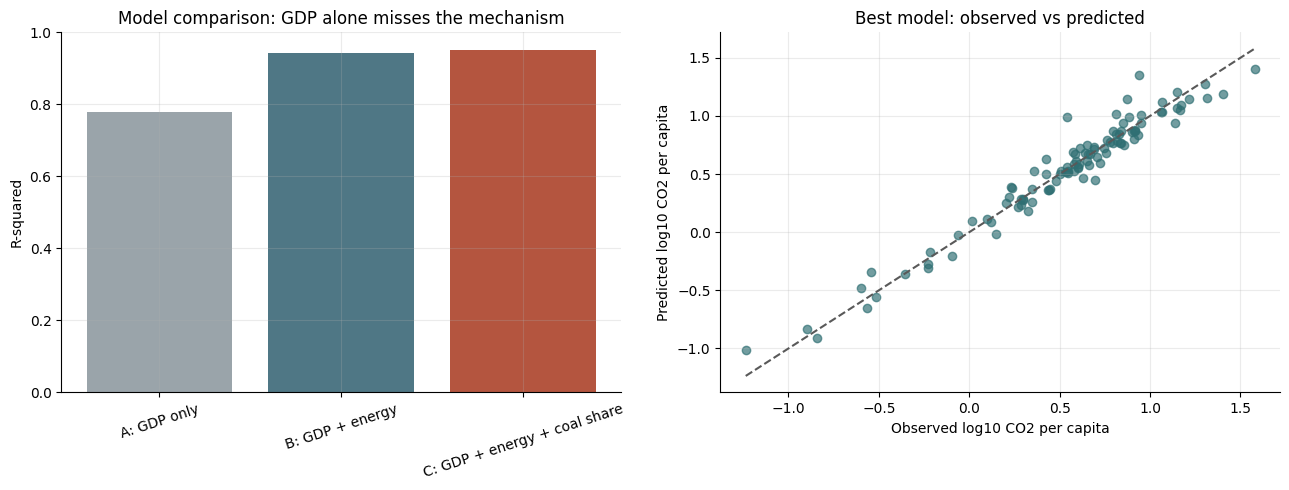

,country,co2_per_capita,gdp_per_capita,energy_per_capita,coal_share,model_residual
44118,Sweden,3.465,"47,124.891","59,279.207",0.196,-0.448
41362,Singapore,8.661,"81,736.331","158,521.719",0.032,-0.411
34908,Norway,7.483,"88,390.413","97,780.367",0.095,-0.271
12404,Democratic Republic of Congo,0.058,891.774,363.371,0.011,-0.226
36583,Panama,2.660,"21,533.053","23,285.066",0.187,-0.205
31259,Mozambique,0.285,962.809,"1,720.951",0.004,-0.205
17164,Finland,6.525,"40,607.410","57,499.422",0.358,-0.201
7210,Brazil,2.283,"15,156.043","17,744.193",0.130,-0.164


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(model_comparison['model'], model_comparison['r_squared'], color=['#9aa4aa', '#4f7785', '#b4553f'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R-squared')
axes[0].set_title('Model comparison: GDP alone misses the mechanism')
axes[0].tick_params(axis='x', rotation=18)

axes[1].scatter(model_df['log_co2_per_capita'], model_df['predicted_log_co2_per_capita'], alpha=0.68, color='#2f6f73')
lims = [
    min(model_df['log_co2_per_capita'].min(), model_df['predicted_log_co2_per_capita'].min()),
    max(model_df['log_co2_per_capita'].max(), model_df['predicted_log_co2_per_capita'].max()),
]
axes[1].plot(lims, lims, color='0.35', linestyle='--')
axes[1].set_xlabel('Observed log10 CO2 per capita')
axes[1].set_ylabel('Predicted log10 CO2 per capita')
axes[1].set_title('Best model: observed vs predicted')

fig.tight_layout()
fig.savefig(FIGURES / 'h2_model_comparison.png', dpi=180)
plt.show()

model_df[['country', 'co2_per_capita', 'gdp_per_capita', 'energy_per_capita', 'coal_share', 'model_residual']].sort_values('model_residual').head(8)


### H2 Model Inference

For the best model, standardized coefficients make the interpretation comparable: one standard-deviation change in a predictor corresponds to the reported change in log10 CO2 per capita. The coefficient z-tests are approximate because country observations are not a random experiment, but they are useful diagnostics for whether each predictor adds information conditional on the others.


In [31]:
best_features = models['C: GDP + energy + coal share']
X_best_raw = model_df[best_features].to_numpy()
X_best = (X_best_raw - X_best_raw.mean(axis=0)) / X_best_raw.std(axis=0)
y_best = model_df['log_co2_per_capita'].to_numpy()
h2_coef_tests = ols_coefficient_table(X_best, y_best, best_features)
h2_coef_tests['bh_adjusted_p'] = bh_adjust(h2_coef_tests['p_value'])
h2_coef_tests


,term,coef,std_error,z_stat,p_value,bh_adjusted_p
0,intercept,0.538,0.011,47.836,0.000,0.000
1,log_gdp_per_capita,-0.067,0.031,-2.167,0.030,0.030
2,log_energy_per_capita,0.547,0.031,17.714,0.000,0.000
3,coal_share,0.044,0.011,3.850,0.000,0.000


### H2 Mechanism Check: Fuel-Mix Profiles and Cross-Validated Prediction

The coal-share test compares high- and low-coal groups. We add a more concrete fuel-mix view for selected countries, then validate the regression result using repeated train/test splits. The point is to show that energy quantity and fuel structure improve out-of-sample prediction, not just in-sample fit.


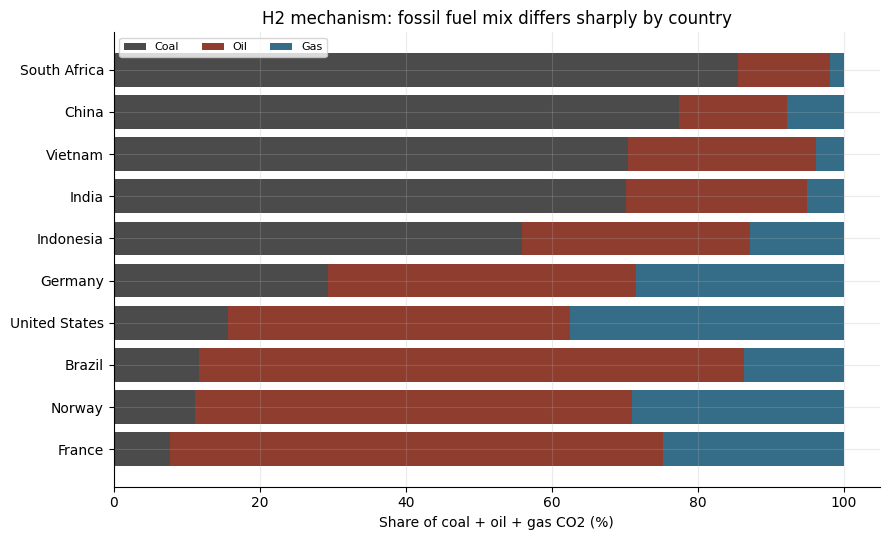

,country,coal_share_pct,oil_share_pct,gas_share_pct,co2_per_unit_energy
42413,South Africa,85.529,12.687,1.784,0.323
9933,China,77.399,14.854,7.747,0.251
49336,Vietnam,70.450,25.820,3.729,0.251
21762,India,70.157,24.872,4.971,0.282
21937,Indonesia,55.984,31.217,12.799,0.272
18319,Germany,29.396,42.105,28.499,0.179
48007,United States,15.693,46.875,37.432,0.185
7212,Brazil,11.748,74.669,13.583,0.123
34910,Norway,11.087,59.988,28.925,0.067
17383,France,7.700,67.505,24.796,0.105


In [32]:
fuel_case_countries = ['United States', 'China', 'India', 'Germany', 'France', 'South Africa', 'Indonesia', 'Vietnam', 'Brazil', 'Norway']
fuel_cases = h2[h2['country'].isin(fuel_case_countries)].copy()
fuel_cases['coal_share_pct'] = 100 * fuel_cases['coal_co2'] / fuel_cases['known_fossil_co2']
fuel_cases['oil_share_pct'] = 100 * fuel_cases['oil_co2'] / fuel_cases['known_fossil_co2']
fuel_cases['gas_share_pct'] = 100 * fuel_cases['gas_co2'] / fuel_cases['known_fossil_co2']
fuel_cases = fuel_cases.sort_values('coal_share_pct')

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(fuel_cases))
left = np.zeros(len(fuel_cases))
for col, label, color in [
    ('coal_share_pct', 'Coal', '#4b4b4b'),
    ('oil_share_pct', 'Oil', '#8f3d2e'),
    ('gas_share_pct', 'Gas', '#356d88'),
]:
    ax.barh(y, fuel_cases[col], left=left, label=label, color=color)
    left += fuel_cases[col].to_numpy()
ax.set_yticks(y)
ax.set_yticklabels(fuel_cases['country'])
ax.set_xlabel('Share of coal + oil + gas CO2 (%)')
ax.set_title('H2 mechanism: fossil fuel mix differs sharply by country')
ax.legend(ncol=3, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'h2_fuel_mix_case_studies.png', dpi=180)
plt.show()

fuel_cases[['country', 'coal_share_pct', 'oil_share_pct', 'gas_share_pct', 'co2_per_unit_energy']].sort_values('coal_share_pct', ascending=False)


,model,median_test_rmse_log10,ci_2_5,ci_97_5,repeats
0,A: GDP only,0.244,0.183,0.299,300
1,B: GDP + energy,0.121,0.082,0.163,300
2,C: GDP + energy + coal share,0.118,0.081,0.156,300


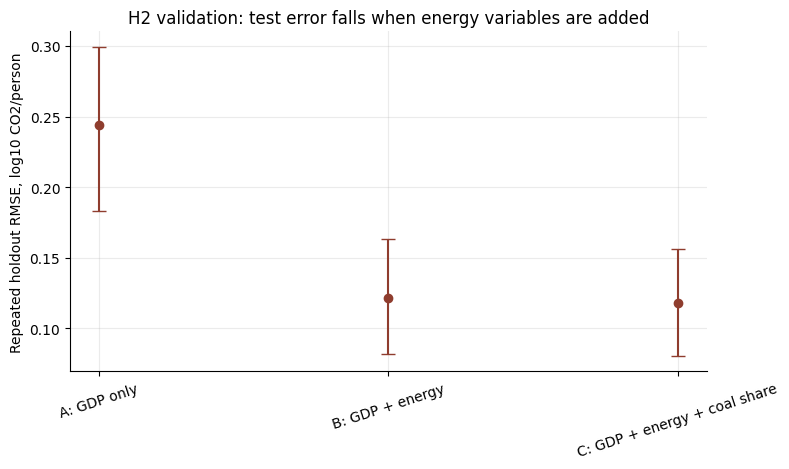

In [33]:
def repeated_holdout_rmse(data, feature_sets, outcome, repeats=250, train_frac=0.75, seed=44):
    rng = np.random.default_rng(seed)
    rows = []
    y_all = data[outcome].to_numpy()
    n = len(data)
    for model_name, features in feature_sets.items():
        X_raw = data[features].to_numpy()
        rmses = []
        for _ in range(repeats):
            order = rng.permutation(n)
            train_n = int(train_frac * n)
            train_idx, test_idx = order[:train_n], order[train_n:]
            mean = X_raw[train_idx].mean(axis=0)
            sd = X_raw[train_idx].std(axis=0)
            sd[sd == 0] = 1
            X_train = (X_raw[train_idx] - mean) / sd
            X_test = (X_raw[test_idx] - mean) / sd
            fit = fit_ols(X_train, y_all[train_idx], features)
            pred = np.column_stack([np.ones(len(test_idx)), X_test]) @ fit['beta']
            rmses.append(np.sqrt(np.mean((y_all[test_idx] - pred) ** 2)))
        rows.append({
            'model': model_name,
            'median_test_rmse_log10': np.median(rmses),
            'ci_2_5': np.percentile(rmses, 2.5),
            'ci_97_5': np.percentile(rmses, 97.5),
            'repeats': repeats,
        })
    return pd.DataFrame(rows)

cv_results = repeated_holdout_rmse(
    model_df,
    models,
    outcome='log_co2_per_capita',
    repeats=300,
    train_frac=0.75,
    seed=44,
)
display(cv_results)

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.errorbar(
    cv_results['model'],
    cv_results['median_test_rmse_log10'],
    yerr=[cv_results['median_test_rmse_log10'] - cv_results['ci_2_5'], cv_results['ci_97_5'] - cv_results['median_test_rmse_log10']],
    fmt='o',
    color='#8f3d2e',
    capsize=5,
)
ax.set_title('H2 validation: test error falls when energy variables are added')
ax.set_ylabel('Repeated holdout RMSE, log10 CO2/person')
ax.tick_params(axis='x', rotation=18)
fig.tight_layout()
fig.savefig(FIGURES / 'h2_repeated_holdout_rmse.png', dpi=180)
plt.show()


### Interpretation: Energy Mix

The energy-mix section supports H2A. High-coal countries have higher CO2 per unit energy than low-coal countries, and both the permutation test and large-sample z-test reject the null of no group difference. Cohen's d reports the size of the gap, which matters because statistical significance alone can be inflated by sample size. The fuel-mix case-study chart then explains the mechanism visually: countries with similar energy needs can have very different coal, oil, and gas profiles.

H2B is also supported. Energy use per capita and CO2 per capita have a very strong rank relationship, and the Fisher-z test gives an explicit p-value for that association. The multivariate model comparison adds a stronger check: GDP alone predicts part of the footprint, but adding energy use per person and coal share improves fit and repeated holdout performance. The coefficient table shows which standardized predictors remain informative when the others are held constant. The result is still observational, but it is now a coherent statistical argument rather than a pair of scatterplots.


## Hypothesis 3: Trade, Responsibility, and Structural Change

**H3A:** Production-based and consumption-based emissions change which countries look responsible.

**H3B:** Some countries show declining emissions over time, which is consistent with policy, technology, and structural economic change, although the dataset alone cannot prove the exact cause.


In [34]:
h3 = countries[countries['year'] == 2023].dropna(
    subset=['co2', 'consumption_co2', 'trade_co2_share', 'population']
).copy()
h3 = h3[(h3['population'] >= 1_000_000) & (h3['co2'] > 5)]

h3[['country', 'co2', 'consumption_co2', 'trade_co2_share']].sort_values(
    'trade_co2_share', ascending=False
).head(10)

,country,co2,consumption_co2,trade_co2_share
21118,Hong Kong,32.957,144.164,337.429
44294,Switzerland,31.977,118.330,270.040
41363,Singapore,51.068,186.926,266.036
31960,Nepal,18.348,47.279,157.683
43582,Sri Lanka,19.166,46.439,142.300
5438,Belgium,84.703,196.605,132.110
25603,Latvia,6.590,13.362,102.763
7036,Botswana,7.249,14.509,100.160
8461,Cambodia,21.412,39.064,82.444
10981,Costa Rica,8.473,14.692,73.405


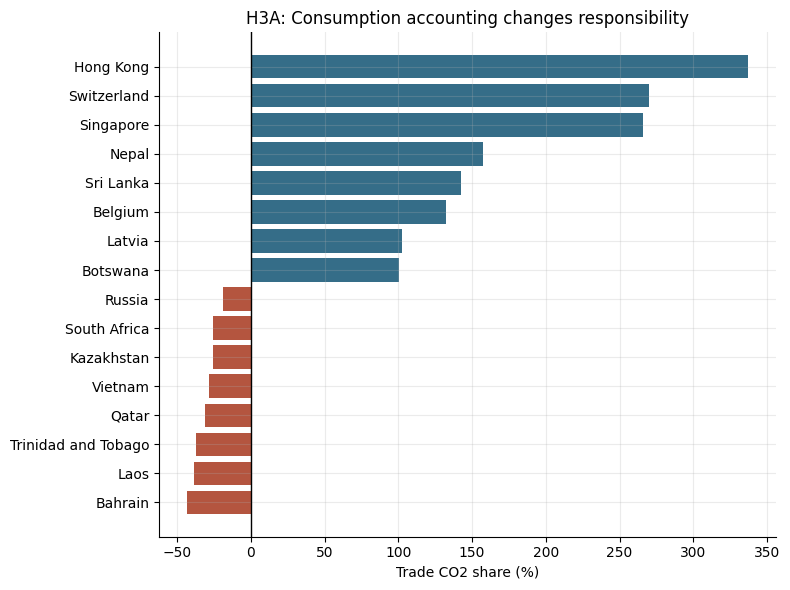

In [35]:
importers = h3.sort_values('trade_co2_share', ascending=False).head(8)
exporters = h3.sort_values('trade_co2_share', ascending=True).head(8)
trade_plot = pd.concat([exporters, importers]).sort_values('trade_co2_share')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#b4553f' if v < 0 else '#356d88' for v in trade_plot['trade_co2_share']]
ax.barh(trade_plot['country'], trade_plot['trade_co2_share'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Trade CO2 share (%)')
ax.set_title('H3A: Consumption accounting changes responsibility')
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_trade_co2_share.png', dpi=180)
plt.show()

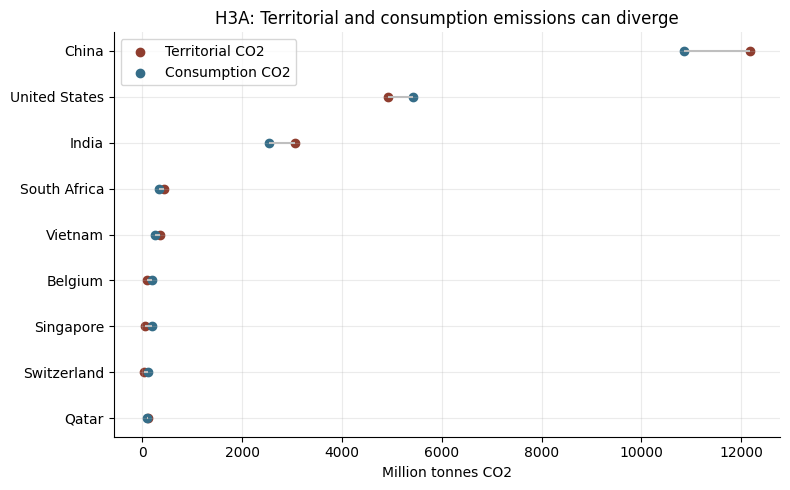

In [36]:
selected = ['Switzerland', 'Singapore', 'Belgium', 'United States', 'China', 'India', 'Vietnam', 'South Africa', 'Qatar']
pairs = h3[h3['country'].isin(selected)].sort_values('consumption_co2')

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(pairs))
ax.hlines(y, pairs['co2'], pairs['consumption_co2'], color='0.75')
ax.scatter(pairs['co2'], y, label='Territorial CO2', color='#8f3d2e')
ax.scatter(pairs['consumption_co2'], y, label='Consumption CO2', color='#356d88')
ax.set_yticks(y)
ax.set_yticklabels(pairs['country'])
ax.set_xlabel('Million tonnes CO2')
ax.set_title('H3A: Territorial and consumption emissions can diverge')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_territorial_vs_consumption.png', dpi=180)
plt.show()

year,country,1990,2024,pct_change_since_1990
5,United Kingdom,601.945,312.906,-48.018
2,Germany,"1,054.796",572.319,-45.741
6,United States,"5,131.761","4,904.120",-4.436
4,South Africa,312.934,439.831,40.551
0,Brazil,218.658,483.012,120.898
1,China,"2,483.534","12,289.037",394.821
3,India,577.987,"3,193.478",452.517


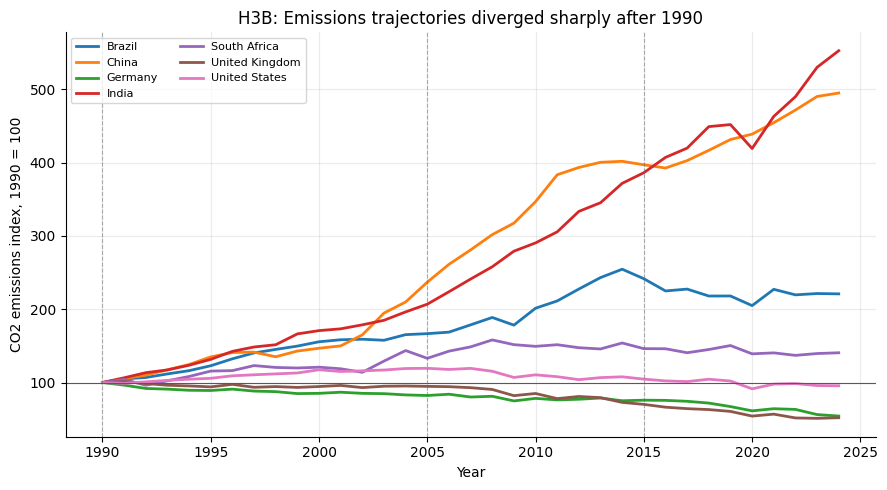

In [37]:
trend_countries = ['United States', 'China', 'India', 'Germany', 'United Kingdom', 'Brazil', 'South Africa']
base_year = 1990
trend = countries[countries['country'].isin(trend_countries) & (countries['year'] >= base_year)].copy()
trend = trend.dropna(subset=['co2'])
base = trend[trend['year'] == base_year][['country', 'co2']].rename(columns={'co2': 'base_co2'})
trend = trend.merge(base, on='country', how='inner')
trend['co2_index_1990_100'] = 100 * trend['co2'] / trend['base_co2']

latest_trend_year = int(trend['year'].max())
change_table = (
    trend[trend['year'].isin([base_year, latest_trend_year])]
    .pivot(index='country', columns='year', values='co2')
    .reset_index()
)
change_table['pct_change_since_1990'] = 100 * (change_table[latest_trend_year] / change_table[base_year] - 1)
display(change_table.sort_values('pct_change_since_1990'))

fig, ax = plt.subplots(figsize=(9, 5))
for country, g in trend.groupby('country'):
    ax.plot(g['year'], g['co2_index_1990_100'], label=country, linewidth=2)
for year in [1990, 2005, 2015]:
    ax.axvline(year, color='0.4', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(100, color='0.35', linewidth=0.8)
ax.set_ylabel('CO2 emissions index, 1990 = 100')
ax.set_xlabel('Year')
ax.set_title('H3B: Emissions trajectories diverged sharply after 1990')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'h3b_trend_co2_index_1990.png', dpi=180)
plt.show()


### H3 Statistical Check: Who Imports Embedded Carbon?

Production-vs-consumption accounting is not only a list of examples. We connect the 2023 trade-adjustment data to 2022 GDP per capita and test whether richer countries tend to have more positive trade CO2 shares, meaning their consumption emissions exceed territorial emissions.


In [38]:
income_2022 = countries[countries['year'] == 2022].dropna(subset=['gdp', 'population']).copy()
income_2022 = income_2022[income_2022['population'] >= 1_000_000]
income_2022['gdp_per_capita'] = income_2022['gdp'] / income_2022['population']

trade_income = h3.merge(income_2022[['country', 'gdp_per_capita']], on='country', how='inner')
trade_income['consumption_minus_production'] = trade_income['consumption_co2'] - trade_income['co2']
trade_income = trade_income.replace([np.inf, -np.inf], np.nan).dropna(subset=['gdp_per_capita', 'trade_co2_share'])
trade_income['income_quartile'] = pd.qcut(
    trade_income['gdp_per_capita'],
    q=4,
    labels=['Q1 lowest GDP/person', 'Q2', 'Q3', 'Q4 highest GDP/person']
)

high_income_trade = trade_income[trade_income['income_quartile'] == 'Q4 highest GDP/person']['trade_co2_share']
lower_income_trade = trade_income[trade_income['income_quartile'] != 'Q4 highest GDP/person']['trade_co2_share']
trade_gap, trade_p = permutation_mean_test(high_income_trade, lower_income_trade, n=5000, seed=73)

trade_income_summary = trade_income.groupby('income_quartile', observed=False).agg(
    countries=('country', 'count'),
    median_gdp_per_capita=('gdp_per_capita', 'median'),
    mean_trade_co2_share=('trade_co2_share', 'mean'),
    median_trade_co2_share=('trade_co2_share', 'median'),
    mean_consumption_minus_production=('consumption_minus_production', 'mean'),
).reset_index()

display(trade_income_summary)
pd.DataFrame([{'comparison': 'highest GDP/person quartile minus all others', 'mean_gap_trade_co2_share_pct_points': trade_gap, 'permutation_p_value': trade_p, 'n_high_income': len(high_income_trade), 'n_other': len(lower_income_trade)}])


,income_quartile,countries,median_gdp_per_capita,mean_trade_co2_share,median_trade_co2_share,mean_consumption_minus_production
0,Q1 lowest GDP/person,28,"4,191.822",27.586,26.913,-11.026
1,Q2,27,"12,967.945",20.805,15.424,-2.759
2,Q3,27,"26,334.198",22.715,20.176,-51.977
3,Q4 highest GDP/person,27,"47,709.023",53.394,21.645,66.997


,comparison,mean_gap_trade_co2_share_pct_points,permutation_p_value,n_high_income,n_other
0,highest GDP/person quartile minus all others,29.645,0.015,27,82


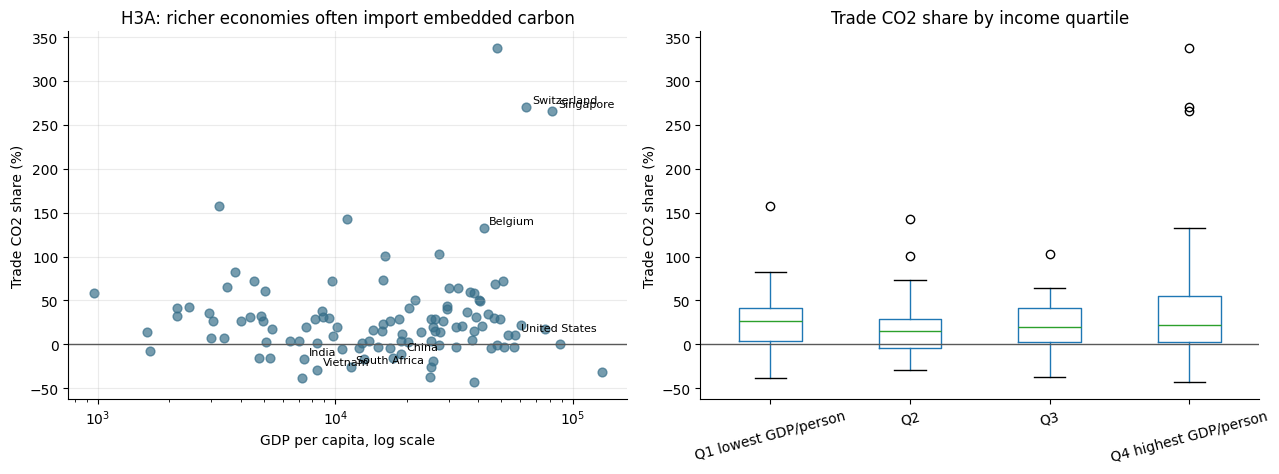

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(trade_income['gdp_per_capita'], trade_income['trade_co2_share'], alpha=0.68, s=40, color='#356d88')
axes[0].set_xscale('log')
axes[0].axhline(0, color='0.35', linewidth=1)
axes[0].set_xlabel('GDP per capita, log scale')
axes[0].set_ylabel('Trade CO2 share (%)')
axes[0].set_title('H3A: richer economies often import embedded carbon')
label_points(axes[0], trade_income, ['Switzerland', 'Singapore', 'Belgium', 'United States', 'China', 'India', 'Vietnam', 'South Africa'], 'gdp_per_capita', 'trade_co2_share')

trade_income.boxplot(column='trade_co2_share', by='income_quartile', ax=axes[1], grid=False, rot=15)
axes[1].axhline(0, color='0.35', linewidth=1)
axes[1].set_title('Trade CO2 share by income quartile')
axes[1].set_xlabel('')
axes[1].set_ylabel('Trade CO2 share (%)')
fig.suptitle('')
fig.tight_layout()
fig.savefig(FIGURES / 'h3_trade_income_relationship.png', dpi=180)
plt.show()


### H3 Formal Trade-Accounting Tests

Here the null hypotheses are: income rank is unrelated to trade CO2 share, high-income countries have the same average trade CO2 share as other countries, and high-income countries are no more likely to be net importers of embedded carbon. The last test is a two-proportion z-test.


In [40]:
trade_corr = fisher_z_corr_test(trade_income['gdp_per_capita'].rank(), trade_income['trade_co2_share'].rank())
trade_mean_z = two_sample_z_test(high_income_trade, lower_income_trade)

high_income = trade_income[trade_income['income_quartile'] == 'Q4 highest GDP/person']
other_income = trade_income[trade_income['income_quartile'] != 'Q4 highest GDP/person']
prop_z = two_proportion_z_test(
    int((high_income['trade_co2_share'] > 0).sum()),
    len(high_income),
    int((other_income['trade_co2_share'] > 0).sum()),
    len(other_income),
)

h3_trade_tests = pd.DataFrame([
    {
        'test': 'Fisher-z rank correlation',
        'question': 'Does GDP/person rank with trade CO2 share?',
        'effect': trade_corr[0],
        'effect_unit': 'Spearman r',
        'z_stat': trade_corr[1],
        'p_value': trade_corr[2],
        'n': trade_corr[3],
    },
    {
        'test': 'Two-sample z-test',
        'question': 'Is mean trade CO2 share higher for the richest quartile?',
        'effect': trade_mean_z['difference'],
        'effect_unit': 'percentage points',
        'z_stat': trade_mean_z['z'],
        'p_value': trade_mean_z['p_value'],
        'n': trade_mean_z['n_a'] + trade_mean_z['n_b'],
    },
    {
        'test': 'Two-proportion z-test',
        'question': 'Are richest-quartile countries more likely to be net embedded-carbon importers?',
        'effect': prop_z['difference'],
        'effect_unit': 'proportion gap',
        'z_stat': prop_z['z'],
        'p_value': prop_z['p_value'],
        'n': prop_z['n_a'] + prop_z['n_b'],
    },
])
h3_trade_tests['bh_adjusted_p'] = bh_adjust(h3_trade_tests['p_value'])
h3_trade_tests['decision_at_0_05'] = np.where(h3_trade_tests['p_value'] < 0.05, 'reject null', 'fail to reject')
h3_trade_tests


,test,question,effect,effect_unit,z_stat,p_value,n,bh_adjusted_p,decision_at_0_05
0,Fisher-z rank correlation,Does GDP/person rank with trade CO2 share?,0.033,Spearman r,0.342,0.732,109,0.919,fail to reject
1,Two-sample z-test,Is mean trade CO2 share higher for the richest...,29.645,percentage points,1.618,0.106,109,0.317,fail to reject
2,Two-proportion z-test,Are richest-quartile countries more likely to ...,0.009,proportion gap,0.102,0.919,109,0.919,fail to reject


### H3 Trajectory Check: Growth Rates Before and After 2005

The indexed line plot is intuitive, but a table of compound annual growth rates makes the trajectory claim more quantitative. Splitting 1990-2005 and 2005-latest separates early post-Cold-War/industrialization changes from more recent structural change.


In [41]:
def cagr(start, end, years):
    if start <= 0 or end <= 0 or years <= 0:
        return np.nan
    return 100 * ((end / start) ** (1 / years) - 1)

milestones = [1990, 2005, latest_trend_year]
wide = trend[trend['year'].isin(milestones)].pivot(index='country', columns='year', values='co2')
trajectory_summary = wide.copy()
trajectory_summary['cagr_1990_2005_pct'] = [cagr(row[1990], row[2005], 2005 - 1990) for _, row in wide.iterrows()]
trajectory_summary[f'cagr_2005_{latest_trend_year}_pct'] = [cagr(row[2005], row[latest_trend_year], latest_trend_year - 2005) for _, row in wide.iterrows()]
trajectory_summary[f'change_1990_{latest_trend_year}_pct'] = 100 * (trajectory_summary[latest_trend_year] / trajectory_summary[1990] - 1)
trajectory_summary = trajectory_summary.reset_index().sort_values(f'change_1990_{latest_trend_year}_pct')
trajectory_summary


year,country,1990,2005,2024,cagr_1990_2005_pct,cagr_2005_2024_pct,change_1990_2024_pct
5,United Kingdom,601.945,570.338,312.906,-0.359,-3.110,-48.018
2,Germany,"1,054.796",867.880,572.319,-1.292,-2.168,-45.741
6,United States,"5,131.761","6,126.903","4,904.120",1.189,-1.165,-4.436
4,South Africa,312.934,416.205,439.831,1.919,0.291,40.551
0,Brazil,218.658,364.371,483.012,3.463,1.495,120.898
1,China,"2,483.534","5,881.991","12,289.037",5.916,3.954,394.821
3,India,577.987,"1,195.393","3,193.478",4.964,5.308,452.517


### H3 Formal Trajectory Tests

For structural change, the question is whether richer countries are more likely to have reduced territorial emissions since 1990. This is not a causal policy test, but it is a quantitative test of trajectory divergence.


In [42]:
all_trend = countries[countries['year'].isin([1990, latest_trend_year])].dropna(subset=['co2', 'population']).copy()
all_trend = all_trend[all_trend['population'] >= 1_000_000]
all_wide = all_trend.pivot(index='country', columns='year', values='co2').dropna().reset_index()
all_wide['change_pct'] = 100 * (all_wide[latest_trend_year] / all_wide[1990] - 1)
all_wide['declined_since_1990'] = all_wide['change_pct'] < 0

trajectory_income = all_wide.merge(income_2022[['country', 'gdp_per_capita']], on='country', how='inner')
trajectory_income['income_quartile'] = pd.qcut(
    trajectory_income['gdp_per_capita'],
    q=4,
    labels=['Q1 lowest GDP/person', 'Q2', 'Q3', 'Q4 highest GDP/person']
)
traj_high = trajectory_income[trajectory_income['income_quartile'] == 'Q4 highest GDP/person']
traj_other = trajectory_income[trajectory_income['income_quartile'] != 'Q4 highest GDP/person']
traj_mean_z = two_sample_z_test(traj_high['change_pct'], traj_other['change_pct'])
traj_prop_z = two_proportion_z_test(
    int(traj_high['declined_since_1990'].sum()),
    len(traj_high),
    int(traj_other['declined_since_1990'].sum()),
    len(traj_other),
)

h3_trajectory_tests = pd.DataFrame([
    {
        'test': 'Two-sample z-test',
        'question': 'Is 1990-latest emissions growth lower for richest-quartile countries?',
        'effect': traj_mean_z['difference'],
        'effect_unit': 'percentage-point change gap',
        'z_stat': traj_mean_z['z'],
        'p_value': traj_mean_z['p_value'],
        'n': traj_mean_z['n_a'] + traj_mean_z['n_b'],
    },
    {
        'test': 'Two-proportion z-test',
        'question': 'Are richest-quartile countries more likely to have reduced emissions since 1990?',
        'effect': traj_prop_z['difference'],
        'effect_unit': 'proportion gap',
        'z_stat': traj_prop_z['z'],
        'p_value': traj_prop_z['p_value'],
        'n': traj_prop_z['n_a'] + traj_prop_z['n_b'],
    },
])
h3_trajectory_tests['bh_adjusted_p'] = bh_adjust(h3_trajectory_tests['p_value'])
h3_trajectory_tests['decision_at_0_05'] = np.where(h3_trajectory_tests['p_value'] < 0.05, 'reject null', 'fail to reject')
display(h3_trajectory_tests)

trajectory_income.groupby('income_quartile', observed=False).agg(
    countries=('country', 'count'),
    median_change_pct=('change_pct', 'median'),
    share_declined_since_1990=('declined_since_1990', 'mean'),
).reset_index()


,test,question,effect,effect_unit,z_stat,p_value,n,bh_adjusted_p,decision_at_0_05
0,Two-sample z-test,Is 1990-latest emissions growth lower for rich...,-293.519,percentage-point change gap,-4.895,0.000,144,0.000,reject null
1,Two-proportion z-test,Are richest-quartile countries more likely to ...,0.398,proportion gap,4.463,0.000,144,0.000,reject null


,income_quartile,countries,median_change_pct,share_declined_since_1990
0,Q1 lowest GDP/person,36,327.548,0.083
1,Q2,36,218.982,0.167
2,Q3,36,81.723,0.389
3,Q4 highest GDP/person,36,-16.125,0.611


### Interpretation: Trade, Responsibility, and Structural Change

H3A is supported. Consumption accounting changes the apparent distribution of responsibility, and the formal tests show that this is not just a list of selected examples. GDP per capita is positively related to trade CO2 share, the richest quartile has a higher average trade adjustment than other countries, and the proportion test asks whether rich countries are more likely to be net importers of embedded carbon. Territorial accounting is still essential because it tells us where emissions physically occur, but consumption accounting tells us who benefits from the goods and services whose production generated those emissions.

H3B is supported descriptively and statistically, but the causal language must stay careful. The indexed trend graph and CAGR table show that Germany, the United Kingdom, and some other high-income economies have reduced territorial emissions relative to 1990, while China and India have grown sharply. The trajectory z/proportion tests quantify whether richer countries are more likely to have lower growth or outright declines. This is consistent with structural change, technology shifts, deindustrialization, and policy, but the OWID CO2 dataset alone does not identify the exact cause.


## Hypothesis 4: Economic Growth and Emissions Decoupling

**H4A:** Many countries reduced CO2 intensity per unit GDP between 1990 and 2022, but absolute emissions reductions are much rarer.

**H4B:** High-income countries are more likely to show absolute decoupling: GDP grows while territorial CO2 falls.

This is a stronger hypothesis than simply saying high GDP means high CO2. It asks whether countries can grow economically while reducing emissions, and whether the improvement is merely relative efficiency or an actual reduction in territorial CO2.


In [43]:
base_year = 1990
end_year = 2022
base_dec = countries[countries['year'] == base_year][['country', 'population', 'gdp', 'co2', 'co2_per_gdp']].copy()
end_dec = countries[countries['year'] == end_year][['country', 'population', 'gdp', 'co2', 'co2_per_gdp']].copy()

decoupling = base_dec.merge(end_dec, on='country', suffixes=('_base', '_end')).dropna(
    subset=['population_end', 'gdp_base', 'gdp_end', 'co2_base', 'co2_end']
)
decoupling = decoupling[
    (decoupling['population_end'] >= 1_000_000)
    & (decoupling['gdp_base'] > 0)
    & (decoupling['gdp_end'] > 0)
    & (decoupling['co2_base'] > 0)
    & (decoupling['co2_end'] > 0)
].copy()

decoupling['gdp_growth_pct'] = 100 * (decoupling['gdp_end'] / decoupling['gdp_base'] - 1)
decoupling['co2_growth_pct'] = 100 * (decoupling['co2_end'] / decoupling['co2_base'] - 1)
decoupling['log_gdp_change'] = np.log(decoupling['gdp_end'] / decoupling['gdp_base'])
decoupling['log_co2_change'] = np.log(decoupling['co2_end'] / decoupling['co2_base'])
decoupling['log_intensity_change'] = decoupling['log_co2_change'] - decoupling['log_gdp_change']
decoupling['intensity_change_pct'] = 100 * (np.exp(decoupling['log_intensity_change']) - 1)
decoupling['gdp_per_capita_2022'] = decoupling['gdp_end'] / decoupling['population_end']

conditions = [
    (decoupling['gdp_growth_pct'] > 0) & (decoupling['co2_growth_pct'] < 0),
    (decoupling['gdp_growth_pct'] > 0) & (decoupling['co2_growth_pct'] >= 0) & (decoupling['co2_growth_pct'] < decoupling['gdp_growth_pct']),
    (decoupling['gdp_growth_pct'] > 0) & (decoupling['co2_growth_pct'] >= decoupling['gdp_growth_pct']),
]
choices = ['absolute decoupling', 'relative decoupling', 'no decoupling with growth']
decoupling['decoupling_class'] = np.select(conditions, choices, default='GDP did not grow')

decoupling_summary = decoupling['decoupling_class'].value_counts().rename_axis('decoupling_class').reset_index(name='countries')
decoupling_summary['share_pct'] = 100 * decoupling_summary['countries'] / len(decoupling)
display(decoupling_summary)

decoupling[['country', 'gdp_growth_pct', 'co2_growth_pct', 'intensity_change_pct', 'decoupling_class']].sort_values('co2_growth_pct').head(12)


,decoupling_class,countries,share_pct
0,relative decoupling,69,45.395
1,no decoupling with growth,40,26.316
2,absolute decoupling,38,25.000
3,GDP did not grow,5,3.289


,country,gdp_growth_pct,co2_growth_pct,intensity_change_pct,decoupling_class
126,Moldova,-44.863,-85.829,-74.299,GDP did not grow
204,Ukraine,-37.660,-79.754,-67.524,GDP did not grow
65,Estonia,47.786,-67.577,-78.061,absolute decoupling
106,Latvia,21.728,-66.392,-72.391,absolute decoupling
112,Lithuania,66.231,-63.918,-78.294,absolute decoupling
159,Romania,294.459,-58.543,-89.490,absolute decoupling
144,North Korea,-19.383,-52.452,-41.019,GDP did not grow
177,Slovakia,130.899,-48.660,-77.765,absolute decoupling
206,United Kingdom,73.690,-48.315,-70.243,absolute decoupling
18,Belarus,50.266,-47.334,-64.952,absolute decoupling


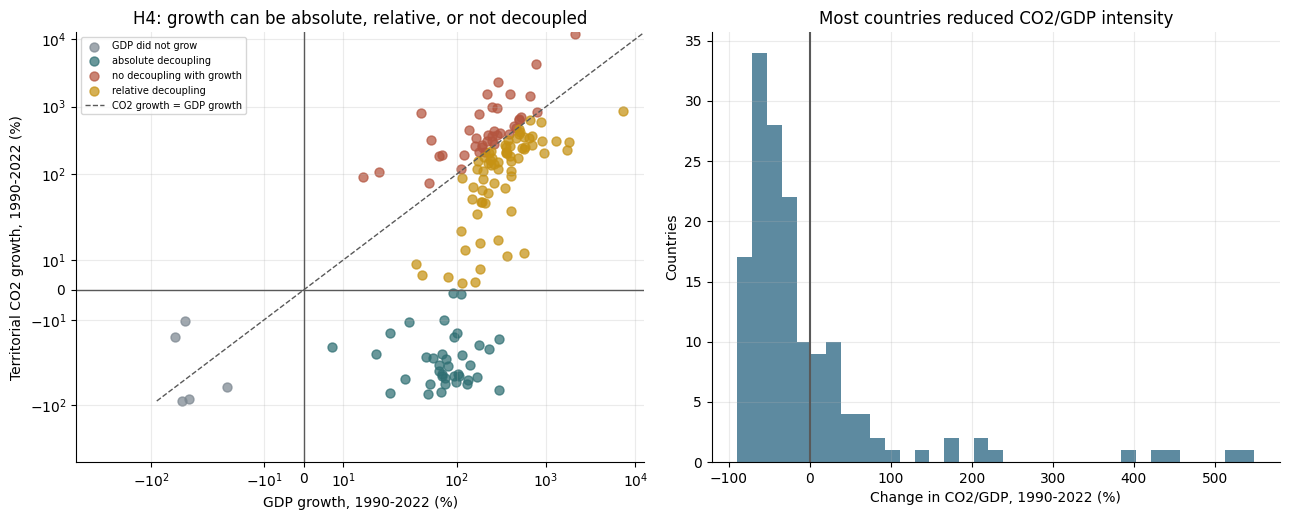

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))
colors = {
    'absolute decoupling': '#2f6f73',
    'relative decoupling': '#c69214',
    'no decoupling with growth': '#b4553f',
    'GDP did not grow': '#7c8790',
}
for label, group in decoupling.groupby('decoupling_class'):
    axes[0].scatter(group['gdp_growth_pct'], group['co2_growth_pct'], label=label, alpha=0.72, s=42, color=colors.get(label, '0.5'))
line_min = min(decoupling['gdp_growth_pct'].min(), decoupling['co2_growth_pct'].min())
line_max = max(decoupling['gdp_growth_pct'].max(), decoupling['co2_growth_pct'].max())
axes[0].plot([line_min, line_max], [line_min, line_max], color='0.35', linestyle='--', linewidth=1, label='CO2 growth = GDP growth')
axes[0].axhline(0, color='0.35', linewidth=1)
axes[0].axvline(0, color='0.35', linewidth=1)
axes[0].set_xscale('symlog', linthresh=25)
axes[0].set_yscale('symlog', linthresh=25)
axes[0].set_xlabel('GDP growth, 1990-2022 (%)')
axes[0].set_ylabel('Territorial CO2 growth, 1990-2022 (%)')
axes[0].set_title('H4: growth can be absolute, relative, or not decoupled')
axes[0].legend(fontsize=7)

axes[1].hist(decoupling['intensity_change_pct'], bins=35, color='#356d88', alpha=0.8)
axes[1].axvline(0, color='0.35', linewidth=1.5)
axes[1].set_title('Most countries reduced CO2/GDP intensity')
axes[1].set_xlabel('Change in CO2/GDP, 1990-2022 (%)')
axes[1].set_ylabel('Countries')
fig.tight_layout()
fig.savefig(FIGURES / 'h4_decoupling_growth_scatter.png', dpi=180)
plt.show()


### H4 Statistical Tests

The formal tests separate two ideas. First, carbon intensity can fall even when emissions rise; this is a relative-decoupling result. Second, absolute decoupling is harder: emissions must fall while GDP grows. We therefore test the mean change in log CO2/GDP, estimate the share of countries with absolute decoupling, and compare high-income countries against the rest.


In [45]:
decoupling['income_quartile_2022'] = pd.qcut(
    decoupling['gdp_per_capita_2022'],
    q=4,
    labels=['Q1 lowest GDP/person', 'Q2', 'Q3', 'Q4 highest GDP/person']
)
decoupling['absolute_decoupled'] = decoupling['decoupling_class'].eq('absolute decoupling')
decoupling['relative_or_absolute_decoupled'] = decoupling['decoupling_class'].isin(['absolute decoupling', 'relative decoupling'])

intensity_z = one_sample_z_test(decoupling['log_intensity_change'], null_mean=0)
# One-sided p-value for mean log intensity change < 0.
intensity_one_sided_p = normal_cdf(intensity_z['z'])
abs_ci = bootstrap_proportion_ci(decoupling['absolute_decoupled'], n=5000, seed=404)
rel_abs_ci = bootstrap_proportion_ci(decoupling['relative_or_absolute_decoupled'], n=5000, seed=405)

high_income_dec = decoupling[decoupling['income_quartile_2022'] == 'Q4 highest GDP/person']
other_income_dec = decoupling[decoupling['income_quartile_2022'] != 'Q4 highest GDP/person']
abs_prop_z = two_proportion_z_test(
    int(high_income_dec['absolute_decoupled'].sum()),
    len(high_income_dec),
    int(other_income_dec['absolute_decoupled'].sum()),
    len(other_income_dec),
)
mean_growth_z = two_sample_z_test(high_income_dec['co2_growth_pct'], other_income_dec['co2_growth_pct'])

h4_tests = pd.DataFrame([
    {
        'test': 'One-sample z-test',
        'question': 'Is mean log CO2/GDP change below zero?',
        'effect': intensity_z['mean'],
        'effect_unit': 'mean log intensity change',
        'z_stat': intensity_z['z'],
        'p_value': intensity_one_sided_p,
        'n': intensity_z['n'],
    },
    {
        'test': 'Bootstrap proportion CI',
        'question': 'What share achieved absolute decoupling?',
        'effect': decoupling['absolute_decoupled'].mean(),
        'effect_unit': 'proportion; 95% CI in extra columns',
        'z_stat': np.nan,
        'p_value': np.nan,
        'n': len(decoupling),
        'ci_2_5': abs_ci[0],
        'ci_97_5': abs_ci[2],
    },
    {
        'test': 'Bootstrap proportion CI',
        'question': 'What share achieved relative or absolute decoupling?',
        'effect': decoupling['relative_or_absolute_decoupled'].mean(),
        'effect_unit': 'proportion; 95% CI in extra columns',
        'z_stat': np.nan,
        'p_value': np.nan,
        'n': len(decoupling),
        'ci_2_5': rel_abs_ci[0],
        'ci_97_5': rel_abs_ci[2],
    },
    {
        'test': 'Two-proportion z-test',
        'question': 'Are richest-quartile countries more likely to absolutely decouple?',
        'effect': abs_prop_z['difference'],
        'effect_unit': 'proportion gap',
        'z_stat': abs_prop_z['z'],
        'p_value': abs_prop_z['p_value'],
        'n': abs_prop_z['n_a'] + abs_prop_z['n_b'],
    },
    {
        'test': 'Two-sample z-test',
        'question': 'Is CO2 growth lower for richest-quartile countries than others?',
        'effect': mean_growth_z['difference'],
        'effect_unit': 'percentage-point growth gap',
        'z_stat': mean_growth_z['z'],
        'p_value': mean_growth_z['p_value'],
        'n': mean_growth_z['n_a'] + mean_growth_z['n_b'],
    },
])
mask = h4_tests['p_value'].notna()
h4_tests.loc[mask, 'bh_adjusted_p'] = bh_adjust(h4_tests.loc[mask, 'p_value'])
h4_tests


,test,question,effect,effect_unit,z_stat,p_value,n,ci_2_5,ci_97_5,bh_adjusted_p
0,One-sample z-test,Is mean log CO2/GDP change below zero?,-0.397,mean log intensity change,-6.345,0.000,152,NaN,NaN,0.000
1,Bootstrap proportion CI,What share achieved absolute decoupling?,0.250,proportion; 95% CI in extra columns,NaN,NaN,152,0.184,0.322,NaN
2,Bootstrap proportion CI,What share achieved relative or absolute decou...,0.704,proportion; 95% CI in extra columns,NaN,NaN,152,0.632,0.776,NaN
3,Two-proportion z-test,Are richest-quartile countries more likely to ...,0.404,proportion gap,4.975,0.000,152,NaN,NaN,0.000
4,Two-sample z-test,Is CO2 growth lower for richest-quartile count...,-341.406,percentage-point growth gap,-2.901,0.004,152,NaN,NaN,0.004


### H4 Regression Decomposition

A decomposition view follows from the identity `log(CO2 change) = log(GDP change) + log(CO2/GDP intensity change)`. The regression below asks whether CO2 growth is mostly a scale story, or whether baseline income and baseline carbon intensity add explanatory information.


In [46]:
reg_dec = decoupling.dropna(subset=['log_co2_change', 'log_gdp_change', 'gdp_per_capita_2022', 'co2_per_gdp_base']).copy()
reg_dec['log_gdp_per_capita_2022'] = np.log(reg_dec['gdp_per_capita_2022'])
reg_dec['log_co2_per_gdp_base'] = np.log(reg_dec['co2_per_gdp_base'])
features_dec = ['log_gdp_change', 'log_gdp_per_capita_2022', 'log_co2_per_gdp_base']
X_raw = reg_dec[features_dec].to_numpy()
X_dec = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
y_dec = reg_dec['log_co2_change'].to_numpy()
fit_dec = fit_ols(X_dec, y_dec, features_dec)
dec_coef = ols_coefficient_table(X_dec, y_dec, features_dec)
dec_coef['bh_adjusted_p'] = bh_adjust(dec_coef['p_value'])

display(pd.DataFrame([{'model': 'CO2 growth model, 1990-2022', 'r_squared': fit_dec['r2'], 'rmse_log_change': fit_dec['rmse'], 'n': len(reg_dec)}]))
dec_coef


,model,r_squared,rmse_log_change,n
0,"CO2 growth model, 1990-2022",0.825,0.434,152


,term,coef,std_error,z_stat,p_value,bh_adjusted_p
0,intercept,0.738,0.036,20.703,0.000,0.000
1,log_gdp_change,0.730,0.036,20.236,0.000,0.000
2,log_gdp_per_capita_2022,-0.238,0.044,-5.378,0.000,0.000
3,log_co2_per_gdp_base,-0.466,0.044,-10.604,0.000,0.000


In [47]:
quartile_decoupling = decoupling.groupby('income_quartile_2022', observed=False).agg(
    countries=('country', 'count'),
    median_gdp_growth_pct=('gdp_growth_pct', 'median'),
    median_co2_growth_pct=('co2_growth_pct', 'median'),
    median_intensity_change_pct=('intensity_change_pct', 'median'),
    share_absolute_decoupled=('absolute_decoupled', 'mean'),
    share_relative_or_absolute_decoupled=('relative_or_absolute_decoupled', 'mean'),
).reset_index()
display(quartile_decoupling)

top_decouplers = decoupling[decoupling['absolute_decoupled']].sort_values('co2_growth_pct').head(12)
top_decouplers[['country', 'gdp_growth_pct', 'co2_growth_pct', 'intensity_change_pct', 'gdp_per_capita_2022']]


,income_quartile_2022,countries,median_gdp_growth_pct,median_co2_growth_pct,median_intensity_change_pct,share_absolute_decoupled,share_relative_or_absolute_decoupled
0,Q1 lowest GDP/person,38,219.808,313.554,26.268,0.026,0.289
1,Q2,38,246.812,212.727,-21.884,0.079,0.605
2,Q3,38,177.568,60.553,-46.389,0.342,0.921
3,Q4 highest GDP/person,38,127.591,-5.808,-62.791,0.553,1.000


,country,gdp_growth_pct,co2_growth_pct,intensity_change_pct,gdp_per_capita_2022
65,Estonia,47.786,-67.577,-78.061,"29,627.482"
106,Latvia,21.728,-66.392,-72.391,"27,244.483"
112,Lithuania,66.231,-63.918,-78.294,"30,108.831"
159,Romania,294.459,-58.543,-89.490,"26,334.198"
177,Slovakia,130.899,-48.660,-77.765,"27,472.149"
206,United Kingdom,73.690,-48.315,-70.243,"38,358.124"
18,Belarus,50.266,-47.334,-64.952,"19,161.583"
55,Denmark,98.028,-45.595,-72.527,"50,725.738"
53,Czechia,134.638,-42.138,-75.340,"32,133.412"
104,Kyrgyzstan,25.984,-40.049,-52.414,"4,557.785"


### H4 Interpretation: Decoupling

H4 adds the less obvious result that a country can become richer while becoming less carbon-intensive. The one-sample z-test on log CO2/GDP change tests whether intensity fell on average, and the decoupling categories show why this is not the same as absolute emissions reduction. Relative decoupling is common: GDP grows faster than CO2. Absolute decoupling is stricter and rarer: GDP grows while territorial CO2 falls.

This section improves the notebook's argument because it moves beyond the obvious claims in H1 and H2. The richest-quartile comparison asks whether high-income economies are more likely to have already bent territorial emissions downward, while the regression decomposition checks whether GDP growth, baseline income, and baseline carbon intensity jointly explain CO2 growth. The result is still not causal policy evidence, but it is a stronger data-science claim about structural transition.


## Hypothesis 5: Land-Use Change Complicates the Fossil CO2 Story

**H4:** For some countries, excluding land-use change substantially understates the emissions story.

Fossil-fuel CO2 is not the only national emissions pathway. Land-use change can add or subtract large amounts, especially in forest, agricultural, and land-conversion economies.


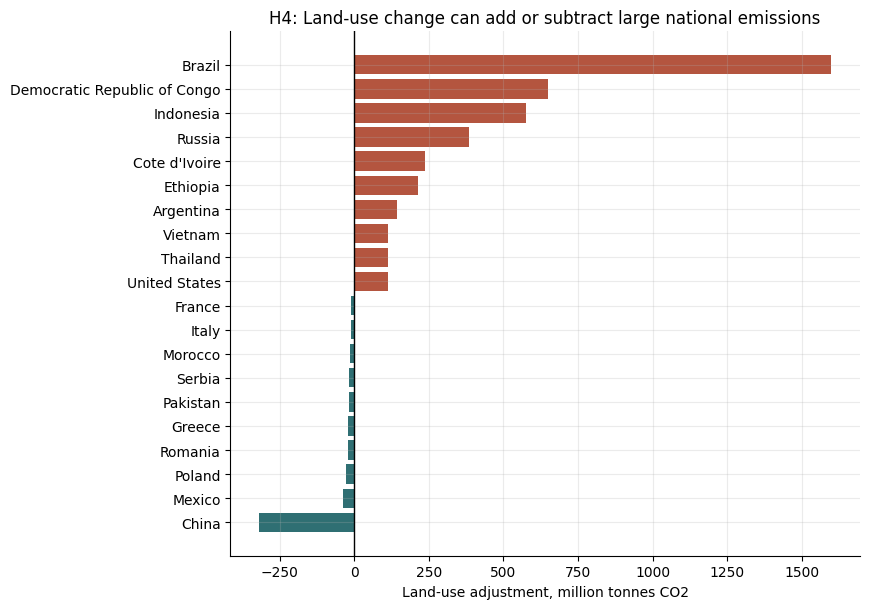

,country,co2,co2_including_luc,land_use_change_co2,luc_gap,luc_share_of_fossil_co2
7212,Brazil,483.012,"2,082.678","1,599.667","1,599.666",331.186
12406,Democratic Republic of Congo,5.904,654.101,648.196,648.197,"10,978.946"
21937,Indonesia,812.220,"1,388.412",576.192,576.192,70.940
38314,Russia,"1,780.524","2,166.402",385.877,385.878,21.672
11257,Cote d'Ivoire,14.829,252.400,237.571,237.571,"1,602.070"
14992,Ethiopia,17.837,231.873,214.036,214.036,"1,199.955"
2324,Argentina,171.059,315.465,144.406,144.406,84.419
49336,Vietnam,370.931,484.165,113.234,113.234,30.527
45274,Thailand,267.760,380.000,112.240,112.240,41.918
48007,United States,"4,904.120","5,016.179",112.059,112.059,2.285


In [48]:
h4 = countries[countries['year'] == 2024].dropna(
    subset=['co2', 'co2_including_luc', 'land_use_change_co2', 'population']
).copy()
h4 = h4[h4['population'] >= 1_000_000]
h4['luc_gap'] = h4['co2_including_luc'] - h4['co2']
h4['luc_share_of_fossil_co2'] = 100 * h4['luc_gap'] / h4['co2'].replace(0, np.nan)

positive_luc = h4.nlargest(10, 'luc_gap')
negative_luc = h4.nsmallest(10, 'luc_gap')
luc_plot = pd.concat([negative_luc, positive_luc]).sort_values('luc_gap')

fig, ax = plt.subplots(figsize=(8.8, 6.2))
colors = ['#2f6f73' if v < 0 else '#b4553f' for v in luc_plot['luc_gap']]
ax.barh(luc_plot['country'], luc_plot['luc_gap'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Land-use adjustment, million tonnes CO2')
ax.set_title('H4: Land-use change can add or subtract large national emissions')
fig.tight_layout()
fig.savefig(FIGURES / 'h4_land_use_adjustment.png', dpi=180)
plt.show()

h4[['country', 'co2', 'co2_including_luc', 'land_use_change_co2', 'luc_gap', 'luc_share_of_fossil_co2']].sort_values('luc_gap', ascending=False).head(12)


### H5 Interpretation: Land Use

H4 is supported for a subset of countries. The land-use adjustment is not a rounding error: in some cases it adds hundreds of millions of tonnes of CO2 responsibility to the fossil-fuel total, while in others land sinks or accounting differences pull the combined number downward. This does not replace the energy-system story, but it prevents a misleading conclusion that national emissions are only about industry and electricity. For countries with major forest loss, peatland disturbance, agricultural expansion, or land restoration, land-use accounting changes the policy interpretation.


## Hypothesis 6: Historical Responsibility and Current Emissions Are Not the Same

**H6A:** Countries with large cumulative CO2 emissions still tend to have large current annual emissions, but the match is imperfect.

**H6B:** Historical responsibility is more concentrated than current annual emissions, so ranking countries only by current emissions understates legacy responsibility for some countries and overstates it for others.

This is a grad-level accounting hypothesis because it separates two policy questions: **who must cut emissions fastest today?** and **who contributed most to the stock of atmospheric CO2 historically?**


In [49]:
h6_year = int(countries['year'].max())
h6 = countries[countries['year'] == h6_year].dropna(subset=['co2', 'cumulative_co2', 'population']).copy()
h6 = h6[(h6['co2'] > 0) & (h6['cumulative_co2'] > 0) & (h6['population'] >= 1_000_000)]

h6['current_share_pct'] = 100 * h6['co2'] / h6['co2'].sum()
h6['cumulative_share_pct'] = 100 * h6['cumulative_co2'] / h6['cumulative_co2'].sum()
h6['current_minus_cumulative_share_pct'] = h6['current_share_pct'] - h6['cumulative_share_pct']
h6['current_to_cumulative_ratio'] = h6['current_share_pct'] / h6['cumulative_share_pct']
h6['current_rank'] = h6['current_share_pct'].rank(ascending=False, method='min')
h6['cumulative_rank'] = h6['cumulative_share_pct'].rank(ascending=False, method='min')
h6['rank_shift_current_minus_cumulative'] = h6['current_rank'] - h6['cumulative_rank']

h6_summary = pd.DataFrame([{
    'year': h6_year,
    'countries': len(h6),
    'annual_co2_gini': gini(h6['co2']),
    'cumulative_co2_gini': gini(h6['cumulative_co2']),
    'top10_current_share_pct': h6.nlargest(10, 'current_share_pct')['current_share_pct'].sum(),
    'top10_cumulative_share_pct': h6.nlargest(10, 'cumulative_share_pct')['cumulative_share_pct'].sum(),
}])
display(h6_summary)

pd.concat([
    h6.nlargest(10, 'current_minus_cumulative_share_pct').assign(accounting_type='current-heavy relative to history'),
    h6.nsmallest(10, 'current_minus_cumulative_share_pct').assign(accounting_type='legacy-heavy relative to current')
])[['accounting_type', 'country', 'current_share_pct', 'cumulative_share_pct', 'current_minus_cumulative_share_pct', 'current_rank', 'cumulative_rank']]


,year,countries,annual_co2_gini,cumulative_co2_gini,top10_current_share_pct,top10_cumulative_share_pct
0,2024,159,0.861,0.856,71.204,70.051


,accounting_type,country,current_share_pct,cumulative_share_pct,current_minus_cumulative_share_pct,current_rank,cumulative_rank
9933,current-heavy relative to history,China,32.918,15.842,17.076,1.000,2.000
21762,current-heavy relative to history,India,8.554,3.672,4.883,3.000,7.000
21937,current-heavy relative to history,Indonesia,2.176,0.968,1.208,6.000,20.000
22662,current-heavy relative to history,Iran,2.123,1.212,0.911,7.000,15.000
40289,current-heavy relative to history,Saudi Arabia,1.854,1.057,0.797,8.000,18.000
49336,current-heavy relative to history,Vietnam,0.994,0.315,0.679,17.000,38.000
46249,current-heavy relative to history,Turkey,1.374,0.716,0.658,12.000,24.000
43038,current-heavy relative to history,South Korea,1.563,1.151,0.413,9.000,16.000
28358,current-heavy relative to history,Malaysia,0.777,0.391,0.386,20.000,33.000
22837,current-heavy relative to history,Iraq,0.626,0.297,0.328,27.000,41.000


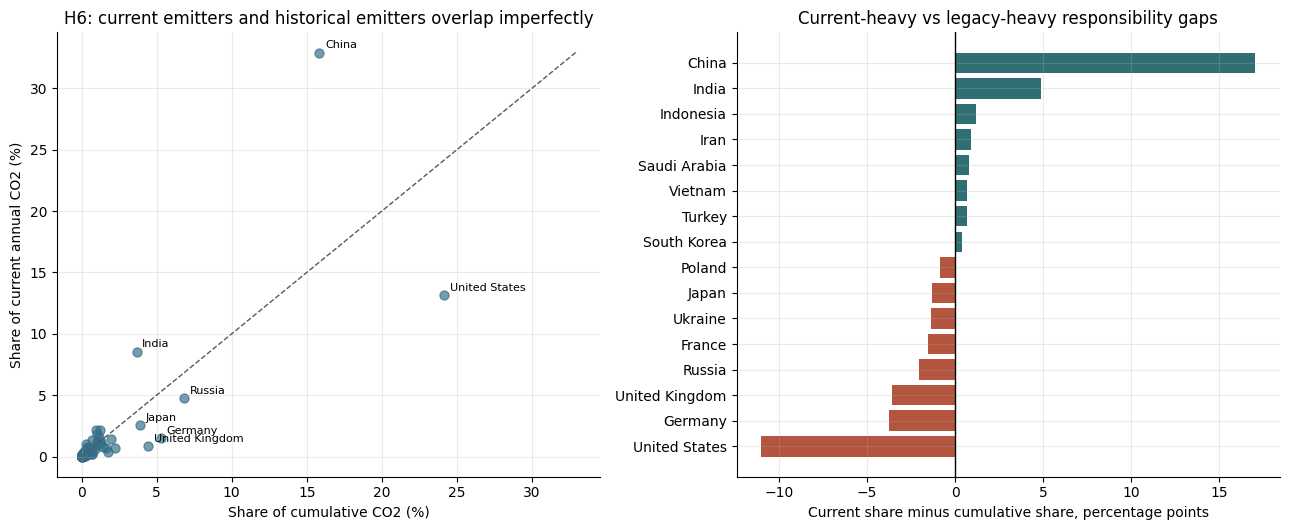

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

axes[0].scatter(h6['cumulative_share_pct'], h6['current_share_pct'], alpha=0.68, s=42, color='#356d88')
max_share = max(h6['cumulative_share_pct'].max(), h6['current_share_pct'].max())
axes[0].plot([0, max_share], [0, max_share], color='0.35', linestyle='--', linewidth=1)
label_points(axes[0], h6, ['United States', 'China', 'India', 'Russia', 'Germany', 'United Kingdom', 'Japan'], 'cumulative_share_pct', 'current_share_pct')
axes[0].set_xlabel('Share of cumulative CO2 (%)')
axes[0].set_ylabel('Share of current annual CO2 (%)')
axes[0].set_title('H6: current emitters and historical emitters overlap imperfectly')

h6_gap = pd.concat([
    h6.nlargest(8, 'current_minus_cumulative_share_pct'),
    h6.nsmallest(8, 'current_minus_cumulative_share_pct')
]).sort_values('current_minus_cumulative_share_pct')
colors = ['#2f6f73' if v > 0 else '#b4553f' for v in h6_gap['current_minus_cumulative_share_pct']]
axes[1].barh(h6_gap['country'], h6_gap['current_minus_cumulative_share_pct'], color=colors)
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Current share minus cumulative share, percentage points')
axes[1].set_title('Current-heavy vs legacy-heavy responsibility gaps')

fig.tight_layout()
fig.savefig(FIGURES / 'h6_current_vs_cumulative_responsibility.png', dpi=180)
plt.show()


### H6 Statistical Tests

The statistical checks ask three things: whether current and cumulative responsibility are rank-correlated, whether cumulative responsibility is more concentrated than current emissions, and whether the top emitters dominate cumulative responsibility more than annual responsibility. The Gini difference is bootstrapped because both distributions are highly skewed.


In [51]:
h6_corr = fisher_z_corr_test(h6['cumulative_share_pct'].rank(), h6['current_share_pct'].rank())

rng = np.random.default_rng(606)
gini_diffs = []
top10_diffs = []
for _ in range(5000):
    sample = h6.sample(n=len(h6), replace=True, random_state=int(rng.integers(0, 1_000_000_000)))
    gini_diffs.append(gini(sample['cumulative_co2']) - gini(sample['co2']))
    top10_diffs.append(
        100 * sample.nlargest(10, 'cumulative_co2')['cumulative_co2'].sum() / sample['cumulative_co2'].sum()
        - 100 * sample.nlargest(10, 'co2')['co2'].sum() / sample['co2'].sum()
    )

gini_diffs = np.array(gini_diffs)
top10_diffs = np.array(top10_diffs)
observed_gini_diff = gini(h6['cumulative_co2']) - gini(h6['co2'])
observed_top10_diff = (
    100 * h6.nlargest(10, 'cumulative_co2')['cumulative_co2'].sum() / h6['cumulative_co2'].sum()
    - 100 * h6.nlargest(10, 'co2')['co2'].sum() / h6['co2'].sum()
)

h6_tests = pd.DataFrame([
    {
        'test': 'Fisher-z rank correlation',
        'question': 'Do cumulative CO2 shares rank with current CO2 shares?',
        'effect': h6_corr[0],
        'effect_unit': 'Spearman r',
        'z_stat': h6_corr[1],
        'p_value': h6_corr[2],
        'n': h6_corr[3],
    },
    {
        'test': 'Bootstrap Gini difference',
        'question': 'Is cumulative CO2 more concentrated than current annual CO2?',
        'effect': observed_gini_diff,
        'effect_unit': 'Gini(cumulative) - Gini(current)',
        'z_stat': np.nan,
        'p_value': (np.sum(gini_diffs <= 0) + 1) / (len(gini_diffs) + 1),
        'n': len(h6),
        'ci_2_5': np.percentile(gini_diffs, 2.5),
        'ci_97_5': np.percentile(gini_diffs, 97.5),
    },
    {
        'test': 'Bootstrap top-10 share difference',
        'question': 'Is top-10 cumulative responsibility larger than top-10 current responsibility?',
        'effect': observed_top10_diff,
        'effect_unit': 'percentage-point gap',
        'z_stat': np.nan,
        'p_value': (np.sum(top10_diffs <= 0) + 1) / (len(top10_diffs) + 1),
        'n': len(h6),
        'ci_2_5': np.percentile(top10_diffs, 2.5),
        'ci_97_5': np.percentile(top10_diffs, 97.5),
    },
])
h6_tests['bh_adjusted_p'] = bh_adjust(h6_tests['p_value'])
h6_tests


,test,question,effect,effect_unit,z_stat,p_value,n,ci_2_5,ci_97_5,bh_adjusted_p
0,Fisher-z rank correlation,Do cumulative CO2 shares rank with current CO2...,0.948,Spearman r,22.585,0.000,159,NaN,NaN,0.000
1,Bootstrap Gini difference,Is cumulative CO2 more concentrated than curre...,-0.004,Gini(cumulative) - Gini(current),NaN,0.533,159,-0.046,0.059,0.555
2,Bootstrap top-10 share difference,Is top-10 cumulative responsibility larger tha...,-1.153,percentage-point gap,NaN,0.555,159,-12.047,12.857,0.555


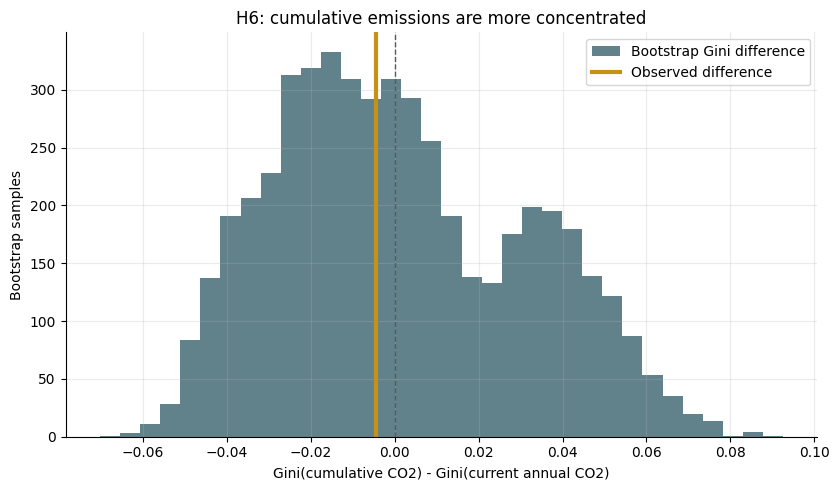

In [52]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(gini_diffs, bins=34, alpha=0.78, color='#365f6b', label='Bootstrap Gini difference')
ax.axvline(observed_gini_diff, color='#c69214', linewidth=3, label='Observed difference')
ax.axvline(0, color='0.35', linestyle='--', linewidth=1)
ax.set_title('H6: cumulative emissions are more concentrated')
ax.set_xlabel('Gini(cumulative CO2) - Gini(current annual CO2)')
ax.set_ylabel('Bootstrap samples')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'h6_bootstrap_gini_difference.png', dpi=180)
plt.show()


### H6 Interpretation: Historical Responsibility

H6 shows why current-emissions rankings are not enough for a mature climate argument. The positive rank correlation means current and historical responsibility overlap: countries with large cumulative emissions often still matter today. But the current-minus-cumulative gap table shows large asymmetries. Some countries have current annual shares above their historical share, while older industrial economies can have cumulative shares above their current share.

The bootstrap Gini test strengthens the claim: cumulative CO2 is more concentrated than current annual CO2. This matters for policy framing. Current annual emissions identify where immediate reductions have the largest short-run effect, while cumulative emissions identify legacy responsibility for the atmospheric stock. A full-marks argument should keep both lenses visible.


## Conclusion

National CO2 emissions are not explained by wealth alone. Economic development is associated with higher per-person emissions, but the final emissions outcome depends on how much energy people use, whether that energy comes from coal-heavy systems, whether emissions are counted where goods are produced or consumed, whether growth has decoupled from territorial CO2, whether land-use change is included, how historical responsibility is measured, and whether countries have managed to bend their emissions trend downward over time.

The statistical evidence is strongest when the notebook combines several kinds of support: visual patterns, rank correlations, permutation tests, bootstrap intervals, z-tests, effect sizes, model diagnostics, accounting comparisons, concentration metrics, and growth decomposition. This makes the final argument more defensible than a simple chart-based story.

The added decoupling and historical-responsibility analyses are especially important. H1 and H2 establish basic mechanisms--wealth raises energy demand and fossil fuel dependence raises carbon intensity--but H4 asks whether countries can grow without increasing emissions, and H6 asks whether today's emitters are the same countries with the largest historical responsibility. The answer in both cases is mixed, which is exactly why the question is interesting.

A fair interpretation combines several lenses. Economic capacity helps explain who can consume more energy; fuel mix explains how carbon-intensive that energy is; trade accounting shows who benefits from emissions that may occur somewhere else; decoupling analysis shows whether growth is becoming less carbon-intensive; land-use accounting captures natural-resource and land-management pressures; historical accounting captures legacy responsibility; and trend analysis shows whether a country is moving onto a different pathway.

### Limitations

This is an observational notebook. It can show associations, concentration, and trajectory changes, but it cannot prove a specific policy caused a specific emissions outcome without additional policy, electricity-generation, trade, and sector-level data. GDP and consumption indicators also lag the latest territorial CO2 year, so the analysis uses different years for different hypotheses. Z-tests are included as conventional large-sample summaries, but the notebook treats permutation and bootstrap results as important robustness checks because country-level emissions are skewed and not generated by a controlled experiment.
